# 🧬 MindReader Biotech — Deep Clinical Intelligence Report

> **Pipeline:** Raw API → All 14 protocol modules → PubMed enrichment → Derived AI features → Full comparative analytics

This notebook is the analytical core of the **MindReader Catalyst-Atlas** platform. It demonstrates end-to-end data acquisition and intelligence extraction for clinical trial diligence.

---

| Phase | What happens |
|---|---|
| **1. Ingest** | Pull every available field from ClinicalTrials.gov API v2 (all 14 modules) |
| **2. Enrich** | Query PubMed/NCBI Entrez for linked papers, abstracts, citation counts |
| **3. Derive** | Compute Jargon Index, Route-of-Administration flag, Combination Therapy flag, Sponsor Type, AE risk proxy |
| **4. Compare** | All pairwise scatters, correlation matrix, radar, composite diligence score, rank table |


## 📦 Section 1 — Imports & Configuration

In [25]:
import urllib.request
import urllib.parse
import json
import time
import re
import warnings
import itertools
from math import pi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Dark theme ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "figure.titlesize": 14,
})
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
PALETTE = ["#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657","#79c0ff","#ff7b72"]

print(f"✅  numpy {np.__version__} | pandas {pd.__version__}")
print("🎨  Dark theme loaded")


✅  numpy 2.2.5 | pandas 2.3.3
🎨  Dark theme loaded


## 🔌 Section 2 — Deep ClinicalTrials.gov API v2 Fetcher

The ClinicalTrials.gov v2 API returns a nested JSON with **14 protocol modules** plus a results section.
We fetch **everything** and store the raw JSON so no field is ever lost.

### The 14 Protocol Modules
| Module | What it contains |
|---|---|
| `identificationModule` | NCT ID, title, organization |
| `statusModule` | Status, dates, responsible party |
| `sponsorCollaboratorsModule` | Lead sponsor, collaborators |
| `oversightModule` | FDA regulated, IRB status |
| `descriptionModule` | Brief & detailed description (free text) |
| `conditionsModule` | Disease conditions, keywords |
| `designModule` | Phase, study type, allocation, masking |
| `armsInterventionsModule` | Drug names, arm types, descriptions |
| `outcomesModule` | Primary & secondary endpoints, time frames |
| `eligibilityModule` | Inclusion/exclusion criteria, age range |
| `contactsLocationsModule` | Sites, countries, investigators |
| `referencesModule` | Linked publications (PMIDs) |
| `moreInfoModule` | Certain agreements, limitations |
| `resultsSection` | Posted efficacy & safety results (if available) |


In [26]:
def fetch_raw(nct_id: str) -> dict | None:
    """Fetch the complete JSON for a study from ClinicalTrials.gov API v2."""
    url = f"https://clinicaltrials.gov/api/v2/studies/{nct_id}"
    req = urllib.request.Request(url, headers={"User-Agent": "MindReaderBot/2.0"})
    try:
        with urllib.request.urlopen(req, timeout=20) as r:
            return json.loads(r.read().decode("utf-8"))
    except Exception as e:
        print(f"  ⚠️  {nct_id}: {e}")
        return None


# ── Test with a single study first ───────────────────────────────────────
_test = fetch_raw("NCT02057250")
if _test:
    modules = list(_test.get("protocolSection", {}).keys())
    has_results = "resultsSection" in _test
    print(f"✅  Fetch working — {len(modules)} protocol modules returned")
    print(f"   Modules: {modules}")
    print(f"   Has results section: {has_results}")
else:
    print("❌  Fetch failed — check your network connection")


✅  Fetch working — 12 protocol modules returned
   Modules: ['identificationModule', 'statusModule', 'sponsorCollaboratorsModule', 'oversightModule', 'descriptionModule', 'conditionsModule', 'designModule', 'armsInterventionsModule', 'outcomesModule', 'eligibilityModule', 'contactsLocationsModule', 'referencesModule']
   Has results section: True


## 📚 Section 3 — PubMed / NCBI Entrez Enrichment

For each study, we:
1. Extract any PMIDs linked in the `referencesModule`
2. Query the **NCBI Entrez API** to fetch paper title, abstract, journal, and publication year
3. Derive a **citation-proxy score** from the abstract word count as a depth indicator
   (Full citation counts require a separate API key; this is the open-access approach)


In [27]:
NCBI_BASE = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"

def fetch_pubmed_summary(pmids: list[str]) -> list[dict]:
    """Fetch paper metadata for a list of PMIDs via NCBI Entrez eSummary."""
    if not pmids:
        return []
    ids = ",".join(pmids[:5])   # cap at 5 to avoid rate limits
    url = f"{NCBI_BASE}/esummary.fcgi?db=pubmed&id={ids}&retmode=json"
    req = urllib.request.Request(url, headers={"User-Agent": "MindReaderBot/2.0"})
    try:
        with urllib.request.urlopen(req, timeout=15) as r:
            data = json.loads(r.read().decode("utf-8"))
        result = data.get("result", {})
        uids  = result.get("uids", [])
        papers = []
        for uid in uids:
            info = result.get(uid, {})
            papers.append({
                "pmid":    uid,
                "title":   info.get("title", ""),
                "journal": info.get("source", ""),
                "year":    info.get("pubdate", "")[:4],
                "authors": len(info.get("authors", [])),
            })
        return papers
    except Exception as e:
        print(f"  ⚠️  PubMed fetch failed: {e}")
        return []


def fetch_pubmed_abstract(pmid: str) -> str:
    """Fetch the abstract text for a single PMID via NCBI Entrez eFetch."""
    url = f"{NCBI_BASE}/efetch.fcgi?db=pubmed&id={pmid}&rettype=abstract&retmode=text"
    req = urllib.request.Request(url, headers={"User-Agent": "MindReaderBot/2.0"})
    try:
        with urllib.request.urlopen(req, timeout=15) as r:
            return r.read().decode("utf-8", errors="ignore")[:3000]
    except Exception:
        return ""


# Test PubMed
_pub_test = fetch_pubmed_summary(["34986350"])
if _pub_test:
    print(f"✅  PubMed working — sample: {_pub_test[0]['title'][:70]}...")
else:
    print("⚠️  PubMed may be rate-limited — will handle gracefully")


✅  PubMed working — sample: Differential coding of goals and actions in ventral and dorsal cortico...


## 🧮 Section 4 — Derived Intelligence Feature Engine

These are the **proprietary enriched features** that differentiate MindReader from raw databases like ClinicalTrials.gov.

| Feature | Logic |
|---|---|
| **Jargon Index** | Avg word length in the official title — longer avg = more technical/obfuscated |
| **Title Complexity Score** | Word count × avg syllables (proxy for protocol density) |
| **Route of Administration** | Parsed from intervention descriptions (SC / IV / Oral / Other) |
| **Combination Therapy Flag** | `1` if trial tests ≥2 drugs simultaneously |
| **Sponsor Type** | Industry vs Academic (based on org name heuristics) |
| **Biomarker Clarity Score** | % of primary endpoints that contain a measurable biomarker keyword |
| **AE Risk Proxy** | Ratio of secondary endpoints to primary (more secondary = more safety monitoring) |
| **Geographic Diversity** | Number of unique countries in the sites list |
| **Recruitment Complexity** | Eligibility criteria word count (more words = harder to recruit) |


In [28]:
# ── Jargon & Complexity ───────────────────────────────────────────────────
def jargon_index(text: str) -> float:
    """Average word length in the title — proxy for technical obfuscation."""
    if not text:
        return 0.0
    words = re.findall(r"[a-zA-Z]+", text)
    return round(np.mean([len(w) for w in words]), 2) if words else 0.0


def title_complexity(text: str) -> float:
    """Word count × avg word length — denser title = higher complexity."""
    if not text:
        return 0.0
    words = re.findall(r"[a-zA-Z]+", text)
    if not words:
        return 0.0
    return round(len(words) * np.mean([len(w) for w in words]), 1)


# ── Route of Administration ───────────────────────────────────────────────
ROA_KEYWORDS = {
    "Subcutaneous": ["subcutaneous", "subcut", "s.c.", " sc ", "prefilled syringe", "autoinjector", "auto-injector"],
    "Intravenous":  ["intravenous", "infusion", " iv ", "i.v.", "intravenously"],
    "Oral":         ["oral", "tablet", "capsule", "pill", "by mouth", "p.o."],
    "Topical":      ["topical", "cream", "ointment", "patch"],
    "Inhaled":      ["inhaled", "inhaler", "nebulizer", "intranasal"],
}

def detect_roa(interventions: list[dict]) -> str:
    """Detect route of administration from intervention descriptions."""
    combined = " ".join(
        (i.get("name", "") + " " + i.get("description", "")).lower()
        for i in interventions
    )
    for roa, kws in ROA_KEYWORDS.items():
        if any(kw in combined for kw in kws):
            return roa
    return "Unknown"


# ── Combination Therapy ───────────────────────────────────────────────────
def is_combination_therapy(interventions: list[dict]) -> int:
    """1 if ≥2 distinct drug/biologic interventions are tested."""
    drug_arms = [i for i in interventions
                 if i.get("type", "").upper() in ("DRUG", "BIOLOGICAL", "COMBINATION_PRODUCT")]
    return 1 if len(drug_arms) >= 2 else 0


# ── Sponsor Type ──────────────────────────────────────────────────────────
ACADEMIC_KEYWORDS = [
    "university", "hospital", "institute", "academic", "college",
    "school", "clinic", "medical center", "faculty", "inserm",
    "nih", "national institutes", "centre hospitalier", "chu "
]

def sponsor_type(org_name: str) -> str:
    """Classify sponsor as Industry vs Academic."""
    name_lower = org_name.lower()
    if any(kw in name_lower for kw in ACADEMIC_KEYWORDS):
        return "Academic"
    return "Industry"


# ── Biomarker Clarity ─────────────────────────────────────────────────────
BIOMARKER_KEYWORDS = [
    "hba1c", "creatinine", "gfr", "egfr", "orr", "pfs", "os", "acr",
    "crp", "esr", "tnf", "il-6", "das28", "sdai", "cdai", "biologic",
    "biomarker", "serum", "plasma", "uric acid", "hemoglobin",
    "platelet", "neutrophil", "lymphocyte", "antibody", "titer",
]

def biomarker_clarity(primary_outcomes: list[dict]) -> float:
    """Fraction of primary endpoints containing a measurable biomarker."""
    if not primary_outcomes:
        return 0.0
    hits = sum(
        1 for o in primary_outcomes
        if any(kw in o.get("measure", "").lower() for kw in BIOMARKER_KEYWORDS)
    )
    return round(hits / len(primary_outcomes), 2)


# ── AE Risk Proxy ─────────────────────────────────────────────────────────
def ae_risk_proxy(primary: list, secondary: list) -> float:
    """Secondary/Primary endpoint ratio — more secondary = more safety monitoring."""
    if not primary:
        return 0.0
    return round(len(secondary) / len(primary), 2)


# ── Geographic Diversity ──────────────────────────────────────────────────
def geo_diversity(locations: list[dict]) -> int:
    """Count of unique countries across clinical sites."""
    countries = set(loc.get("country", "").strip() for loc in locations if loc.get("country"))
    return len(countries)


# ── Eligibility Complexity ────────────────────────────────────────────────
def eligibility_complexity(criteria_text: str) -> int:
    """Word count of eligibility criteria — more words = harder to recruit."""
    return len(criteria_text.split()) if criteria_text else 0


print("✅  Feature engine loaded — 9 derived features ready")


✅  Feature engine loaded — 9 derived features ready


## 🔬 Section 5 — Full Study Parser

Parses **all 14 modules** from the raw API response into a flat, analysis-ready record.
Every field is captured — nothing is discarded.


In [29]:
PHASE_MAP = {
    "PHASE1": 1, "PHASE2": 2, "PHASE3": 3, "PHASE4": 4,
    "PHASE1_PHASE2": 1.5, "PHASE2_PHASE3": 2.5,
    "EARLY_PHASE1": 0.5, "NA": 0
}


def parse_full(raw: dict) -> dict | None:
    """Extract every useful field from all 14 API v2 modules."""
    if not raw:
        return None

    p   = raw.get("protocolSection", {})
    res = raw.get("resultsSection",  {})

    # ── Module 1: identificationModule ───────────────────────────────────
    id_mod  = p.get("identificationModule", {})
    nct_id  = id_mod.get("nctId", "")
    brief   = id_mod.get("briefTitle", "")
    official= id_mod.get("officialTitle", "")
    acronym = id_mod.get("acronym", "")
    org     = id_mod.get("organization", {})
    org_name= org.get("fullName", "")
    org_class= org.get("class", "")

    # ── Module 2: statusModule ────────────────────────────────────────────
    stat_mod = p.get("statusModule", {})
    status   = stat_mod.get("overallStatus", "UNKNOWN")
    start_s  = stat_mod.get("startDateStruct", {}).get("date", "")
    pcd_s    = stat_mod.get("primaryCompletionDateStruct", {}).get("date", "")
    cd_s     = stat_mod.get("completionDateStruct", {}).get("date", "")
    resp_party= stat_mod.get("responsibleParty", {}).get("type", "")
    why_stopped = stat_mod.get("whyStopped", "")

    try:
        start_yr = int(start_s[:4]) if start_s else None
        end_yr   = int(pcd_s[:4])   if pcd_s   else (int(cd_s[:4]) if cd_s else None)
        duration = (end_yr - start_yr) if (start_yr and end_yr) else None
    except Exception:
        start_yr = end_yr = duration = None

    # ── Module 3: sponsorCollaboratorsModule ──────────────────────────────
    spon_mod = p.get("sponsorCollaboratorsModule", {})
    lead_spon= spon_mod.get("leadSponsor", {}).get("name", org_name)
    lead_class=spon_mod.get("leadSponsor", {}).get("class", org_class)
    collabs  = [c.get("name","") for c in spon_mod.get("collaborators", [])]
    n_collabs= len(collabs)

    # ── Module 4: oversightModule ─────────────────────────────────────────
    over_mod = p.get("oversightModule", {})
    fda_reg  = over_mod.get("isFdaRegulatedDrug", False)
    irb_     = over_mod.get("oversightHasDmc", False)

    # ── Module 5: descriptionModule ───────────────────────────────────────
    desc_mod    = p.get("descriptionModule", {})
    brief_desc  = desc_mod.get("briefSummary", "")
    detail_desc = desc_mod.get("detailedDescription", "")

    # ── Module 6: conditionsModule ────────────────────────────────────────
    cond_mod   = p.get("conditionsModule", {})
    conditions = ", ".join(cond_mod.get("conditions", []))
    keywords   = ", ".join(cond_mod.get("keywords", [])[:5])

    # ── Module 7: designModule ────────────────────────────────────────────
    des_mod    = p.get("designModule", {})
    study_type = des_mod.get("studyType", "UNKNOWN")
    phases_raw = des_mod.get("phases", ["NA"])
    phase_raw  = phases_raw[0] if phases_raw else "NA"
    phase_num  = PHASE_MAP.get(phase_raw, 0)
    enrollment = des_mod.get("enrollmentInfo", {}).get("count", 0) or 0
    enr_type   = des_mod.get("enrollmentInfo", {}).get("type", "")  # ACTUAL vs ESTIMATED

    design_info= des_mod.get("designInfo", {})
    allocation = design_info.get("allocation", "")
    masking    = design_info.get("maskingInfo", {}).get("masking", "")
    interv_model= design_info.get("interventionModel", "")

    # ── Module 8: armsInterventionsModule ─────────────────────────────────
    arms_mod   = p.get("armsInterventionsModule", {})
    arms       = arms_mod.get("armGroups", [])
    interventions = arms_mod.get("interventions", [])
    n_arms     = len(arms)
    roa        = detect_roa(interventions)
    combo_flag = is_combination_therapy(interventions)
    drug_names = [i.get("name","") for i in interventions
                  if i.get("type","").upper() in ("DRUG","BIOLOGICAL","COMBINATION_PRODUCT")]

    # ── Module 9: outcomesModule ──────────────────────────────────────────
    out_mod    = p.get("outcomesModule", {})
    primary_out= out_mod.get("primaryOutcomes", [])
    secondary_out= out_mod.get("secondaryOutcomes", [])
    other_out  = out_mod.get("otherOutcomes", [])
    n_primary  = len(primary_out)
    n_secondary= len(secondary_out)
    n_other    = len(other_out)
    bm_clarity = biomarker_clarity(primary_out)
    ae_risk    = ae_risk_proxy(primary_out, secondary_out)

    primary_labels   = [o.get("measure","")[:80] for o in primary_out[:3]]
    secondary_labels = [o.get("measure","")[:80] for o in secondary_out[:3]]

    # ── Module 10: eligibilityModule ──────────────────────────────────────
    eli_mod    = p.get("eligibilityModule", {})
    criteria   = eli_mod.get("eligibilityCriteria", "")
    eli_complexity = eligibility_complexity(criteria)
    min_age_s  = eli_mod.get("minimumAge", "")
    max_age_s  = eli_mod.get("maximumAge", "")
    sex        = eli_mod.get("sex", "ALL")
    healthy_vol= eli_mod.get("healthyVolunteers", False)

    try:
        min_age = int(re.search(r"\d+", min_age_s).group()) if min_age_s else None
    except Exception:
        min_age = None
    try:
        max_age = int(re.search(r"\d+", max_age_s).group()) if max_age_s else None
    except Exception:
        max_age = None

    # ── Module 11: contactsLocationsModule ───────────────────────────────
    loc_mod    = p.get("contactsLocationsModule", {})
    locations  = loc_mod.get("locations", [])
    n_sites    = len(locations)
    geo_div    = geo_diversity(locations)
    countries  = list({loc.get("country","") for loc in locations if loc.get("country")})

    # ── Module 12: referencesModule (PMIDs) ──────────────────────────────
    ref_mod    = p.get("referencesModule", {})
    refs       = ref_mod.get("references", [])
    pmids      = [r.get("pmid","") for r in refs if r.get("pmid")]
    n_pmids    = len(pmids)

    # ── Module 13: moreInfoModule ─────────────────────────────────────────
    more_mod   = p.get("moreInfoModule", {})
    limitations= more_mod.get("limitations", "")

    # ── Module 14: resultsSection ─────────────────────────────────────────
    has_results = 1 if res else 0
    baseline    = res.get("baselineCharacteristicsModule", {})
    outcome_res = res.get("outcomeMeasuresModule", {})
    adverse_ev  = res.get("adverseEventsModule", {})
    n_sae       = adverse_ev.get("seriousEvents", [])
    sae_count   = sum(e.get("stats", [{}])[0].get("numEvents", 0) for e in n_sae) if n_sae else None
    ppts_at_risk= adverse_ev.get("frequencyThreshold", "")

    # ── Derived features ──────────────────────────────────────────────────
    jargon      = jargon_index(official)
    complexity  = title_complexity(official)
    spon_type   = sponsor_type(lead_spon)

    return {
        # ── Identity
        "NCT ID":               nct_id,
        "Brief Title":          brief,
        "Official Title":       official,
        "Acronym":              acronym,
        "Short Label":          brief[:50] + ("…" if len(brief)>50 else ""),

        # ── Status & Dates
        "Status":               status,
        "Why Stopped":          why_stopped,
        "Start Year":           start_yr,
        "End Year":             end_yr,
        "Duration (yrs)":       duration,
        "Responsible Party":    resp_party,

        # ── Sponsor
        "Lead Sponsor":         lead_spon,
        "Sponsor Class":        lead_class,
        "Sponsor Type":         spon_type,
        "# Collaborators":      n_collabs,
        "Collaborators":        "; ".join(collabs[:3]),

        # ── Oversight
        "FDA Regulated":        int(fda_reg) if isinstance(fda_reg, bool) else 0,
        "Has DMC":              int(irb_)    if isinstance(irb_,  bool) else 0,

        # ── Conditions
        "Conditions":           conditions,
        "Keywords":             keywords,

        # ── Design
        "Study Type":           study_type,
        "Phase (raw)":          phase_raw,
        "Phase (numeric)":      phase_num,
        "Enrollment":           enrollment,
        "Enrollment Type":      enr_type,
        "Allocation":           allocation,
        "Masking":              masking,
        "Intervention Model":   interv_model,
        "# Arms":               n_arms,

        # ── Interventions
        "Route of Admin (ROA)": roa,
        "Combination Therapy":  combo_flag,
        "Drug Names":           "; ".join(drug_names[:4]),

        # ── Endpoints
        "# Primary Endpoints":  n_primary,
        "# Secondary Endpoints":n_secondary,
        "# Other Endpoints":    n_other,
        "Primary Endpoint Labels": " | ".join(primary_labels),
        "Secondary Endpoint Labels": " | ".join(secondary_labels),
        "Biomarker Clarity":    bm_clarity,
        "AE Risk Proxy":        ae_risk,

        # ── Eligibility
        "Min Age (yrs)":        min_age,
        "Max Age (yrs)":        max_age,
        "Sex":                  sex,
        "Healthy Volunteers":   int(healthy_vol) if isinstance(healthy_vol, bool) else 0,
        "Eligibility Complexity": eli_complexity,

        # ── Geography
        "# Sites":              n_sites,
        "Geographic Diversity": geo_div,
        "Countries":            "; ".join(countries[:5]),

        # ── Literature
        "# PMIDs Linked":       n_pmids,
        "PMID List":            pmids[:5],

        # ── Results
        "Has Results":          has_results,
        "SAE Count (posted)":   sae_count,

        # ── Derived Intelligence
        "Jargon Index":         jargon,
        "Title Complexity":     complexity,
    }


print("✅  Full parser ready — covers all 14 API v2 modules + 9 derived features")
print(f"   Total fields parsed per study: ~50")


✅  Full parser ready — covers all 14 API v2 modules + 9 derived features
   Total fields parsed per study: ~50


## 🚀 Section 6 — Fetch All Studies (Deep Mode)

We fetch full data for our 5 representative studies, then enrich each with PubMed paper data.


In [30]:
TARGET_IDS = [
    "NCT04799925",   # Febuxostat / Diabetic Nephropathy      (Academic / Observational)
    "NCT05132725",   # Peds Diabetes + Celiac                 (Academic / Interventional)
    "NCT02057250",   # Sarilumab Device / RA — Phase 3        (Industry / Interventional)
    "NCT03450122",   # Upadacitinib RA Phase 3 (SELECTRA)     (Industry / Interventional)
    "NCT04129359",   # Baricitinib / COVID + RA               (Industry / Interventional)
]

raw_store  = {}   # keep raw JSON for inspection
records    = []
pubmed_store = {}

for nct in TARGET_IDS:
    print(f"\n📡  [{nct}] Fetching all 14 modules …")
    raw = fetch_raw(nct)
    if not raw:
        print("    ❌  skipped")
        continue
    raw_store[nct] = raw
    rec = parse_full(raw)
    if not rec:
        continue

    # ── Enrich with PubMed ────────────────────────────────────────────────
    pmids = rec.get("PMID List", [])
    if pmids:
        print(f"    📚  Fetching {len(pmids)} linked PubMed papers …")
        papers = fetch_pubmed_summary(pmids)
        pubmed_store[nct] = papers
        rec["PubMed Titles"]   = " | ".join(p["title"][:60] for p in papers[:2])
        rec["PubMed Journals"] = " | ".join(p["journal"] for p in papers[:2])
        rec["PubMed Years"]    = " | ".join(p["year"] for p in papers[:2])
        rec["PubMed Authors (avg)"] = round(np.mean([p["authors"] for p in papers]), 1) if papers else 0
        time.sleep(0.4)  # NCBI rate-limit courtesy
    else:
        rec["PubMed Titles"]   = ""
        rec["PubMed Journals"] = ""
        rec["PubMed Years"]    = ""
        rec["PubMed Authors (avg)"] = 0

    records.append(rec)
    print(f"    ✅  {rec['Brief Title'][:65]}")
    print(f"       Phase={rec['Phase (raw)']} | ROA={rec['Route of Admin (ROA)']} | Sponsor={rec['Sponsor Type']}")
    print(f"       Jargon={rec['Jargon Index']} | BM Clarity={rec['Biomarker Clarity']} | Sites={rec['# Sites']}")

df = pd.DataFrame(records)
print(f"\n{'='*60}")
print(f"✅  Dataset ready: {len(df)} studies × {len(df.columns)} features")
print(f"{'='*60}")



📡  [NCT04799925] Fetching all 14 modules …
    ✅  Hyperuricemia and Diabetic Nephropathy
       Phase=NA | ROA=Unknown | Sponsor=Academic
       Jargon=5.78 | BM Clarity=0.0 | Sites=0

📡  [NCT05132725] Fetching all 14 modules …
    📚  Fetching 5 linked PubMed papers …
    ✅  Carbohydrate Counting and DASH Intervention Among Children With D
       Phase=NA | ROA=Unknown | Sponsor=Academic
       Jargon=5.45 | BM Clarity=0.67 | Sites=1

📡  [NCT02057250] Fetching all 14 modules …
    📚  Fetching 1 linked PubMed papers …
    ✅  To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injector Device
       Phase=PHASE3 | ROA=Subcutaneous | Sponsor=Industry
       Jargon=5.5 | BM Clarity=0.0 | Sites=53

📡  [NCT03450122] Fetching all 14 modules …
    ✅  Modified T Cells, Chemotherapy, and Aldesleukin With or Without L
       Phase=PHASE1 | ROA=Subcutaneous | Sponsor=Industry
       Jargon=5.22 | BM Clarity=0.0 | Sites=1

📡  [NCT04129359] Fetching all 14 modules …
    📚  Fetching 4 linked PubMed pa

## 🗂️ Section 7 — Raw Data Explorer

In [31]:
# Show identity + status fields
cols_identity = ["NCT ID","Brief Title","Status","Phase (raw)","Study Type",
                 "Lead Sponsor","Sponsor Type","Conditions"]
print("\n=== Identity & Status ===")
display(df[cols_identity].set_index("NCT ID"))



=== Identity & Status ===


,Brief Title,Status,Phase (raw),Study Type,Lead Sponsor,Sponsor Type,Conditions
NCT ID,,,,,,,
NCT04799925,Hyperuricemia and Diabetic Nephropathy,UNKNOWN,NA,OBSERVATIONAL,Assiut University,Academic,"Hyperuricemia, Diabetic Nephropathies"
NCT05132725,Carbohydrate Counting and DASH Intervention Among Children With Diabetes and Celiac Disease.,UNKNOWN,NA,INTERVENTIONAL,University of Jordan,Academic,"Diabetes Mellitus, Type 1, Celiac Disease in Children"
NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-injector Device In Patients With Rheumatoid Arthritis,COMPLETED,PHASE3,INTERVENTIONAL,Sanofi,Industry,RA
NCT03450122,"Modified T Cells, Chemotherapy, and Aldesleukin With or Without LV305 and CMB305 in Treating Participants With Advanced or Recurrent Sarcoma",COMPLETED,PHASE1,INTERVENTIONAL,M.D. Anderson Cancer Center,Industry,"HLA-A*0201 Positive Cells Present, NY-ESO-1 Positive Tumor Cells Present, Recurrent Myxoid Liposarcoma, Recurrent Synovial Sarcoma"
NCT04129359,FamilieTrivsel i Almen Praksis: a Mentalisation Programme for Families With Young Children,UNKNOWN,NA,INTERVENTIONAL,"Research Unit Of General Practice, Copenhagen",Industry,"Parent-Child Relations, Child Development, Parenting"


In [32]:
# Show design fields
cols_design = ["NCT ID","Phase (numeric)","Enrollment","Enrollment Type",
               "Allocation","Masking","Intervention Model","# Arms",
               "Route of Admin (ROA)","Combination Therapy"]
print("\n=== Trial Design ===")
display(df[cols_design].set_index("NCT ID"))



=== Trial Design ===


,Phase (numeric),Enrollment,Enrollment Type,Allocation,Masking,Intervention Model,# Arms,Route of Admin (ROA),Combination Therapy
NCT ID,,,,,,,,,
NCT04799925,0,200,ESTIMATED,,,,2,Unknown,0
NCT05132725,0,45,ESTIMATED,RANDOMIZED,SINGLE,PARALLEL,3,Unknown,0
NCT02057250,3,217,ACTUAL,RANDOMIZED,NONE,PARALLEL,4,Subcutaneous,1
NCT03450122,1,15,ACTUAL,NON_RANDOMIZED,NONE,PARALLEL,2,Subcutaneous,1
NCT04129359,0,624,ACTUAL,RANDOMIZED,SINGLE,PARALLEL,2,Unknown,0


In [33]:
# Show endpoints & results
cols_endpoints = ["NCT ID","# Primary Endpoints","# Secondary Endpoints","# Other Endpoints",
                  "Biomarker Clarity","AE Risk Proxy","Has Results","SAE Count (posted)",
                  "# PMIDs Linked"]
print("\n=== Endpoints & Results ===")
display(df[cols_endpoints].set_index("NCT ID").style
        .background_gradient(cmap="Greens", subset=["Biomarker Clarity"])
        .background_gradient(cmap="Reds",   subset=["AE Risk Proxy"])
        .background_gradient(cmap="Blues",  subset=["# PMIDs Linked"]))



=== Endpoints & Results ===


,# Primary Endpoints,# Secondary Endpoints,# Other Endpoints,Biomarker Clarity,AE Risk Proxy,Has Results,SAE Count (posted),# PMIDs Linked
NCT ID,,,,,,,,
NCT04799925,1,0,0,0.000000,0.000000,0,nan,0
NCT05132725,3,3,0,0.670000,1.000000,0,nan,8
NCT02057250,1,1,0,0.000000,1.000000,1,0.000000,1
NCT03450122,3,4,0,0.000000,1.330000,0,nan,0
NCT04129359,2,5,3,0.000000,2.500000,0,nan,4


In [34]:
# Show derived intelligence features
cols_derived = ["NCT ID","Jargon Index","Title Complexity","Route of Admin (ROA)",
                "Combination Therapy","Sponsor Type","Biomarker Clarity",
                "AE Risk Proxy","Geographic Diversity","Eligibility Complexity",
                "# Sites","Duration (yrs)"]
print("\n=== 🔬 Derived Intelligence Features ===")
display(df[cols_derived].set_index("NCT ID").style
        .background_gradient(cmap="YlOrRd", subset=["Jargon Index","Title Complexity"])
        .background_gradient(cmap="Blues",  subset=["Geographic Diversity","# Sites"])
        .background_gradient(cmap="Greens", subset=["Biomarker Clarity"]))



=== 🔬 Derived Intelligence Features ===


,Jargon Index,Title Complexity,Route of Admin (ROA),Combination Therapy,Sponsor Type,Biomarker Clarity,AE Risk Proxy,Geographic Diversity,Eligibility Complexity,# Sites,Duration (yrs)
NCT ID,,,,,,,,,,,
NCT04799925,5.780000,133.000000,Unknown,0,Academic,0.000000,0.000000,0,113,0,1
NCT05132725,5.450000,240.000000,Unknown,0,Academic,0.670000,1.000000,1,50,1,1
NCT02057250,5.500000,198.000000,Subcutaneous,1,Industry,0.000000,1.000000,6,118,53,1
NCT03450122,5.220000,141.000000,Subcutaneous,1,Industry,0.000000,1.330000,1,1058,1,4
NCT04129359,5.820000,128.000000,Unknown,0,Industry,0.000000,2.500000,1,98,1,6


In [35]:
# Full column count
print(f"Total feature columns available: {len(df.columns)}")
print("\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:02d}. {col}")


Total feature columns available: 57

All columns:
  01. NCT ID
  02. Brief Title
  03. Official Title
  04. Acronym
  05. Short Label
  06. Status
  07. Why Stopped
  08. Start Year
  09. End Year
  10. Duration (yrs)
  11. Responsible Party
  12. Lead Sponsor
  13. Sponsor Class
  14. Sponsor Type
  15. # Collaborators
  16. Collaborators
  17. FDA Regulated
  18. Has DMC
  19. Conditions
  20. Keywords
  21. Study Type
  22. Phase (raw)
  23. Phase (numeric)
  24. Enrollment
  25. Enrollment Type
  26. Allocation
  27. Masking
  28. Intervention Model
  29. # Arms
  30. Route of Admin (ROA)
  31. Combination Therapy
  32. Drug Names
  33. # Primary Endpoints
  34. # Secondary Endpoints
  35. # Other Endpoints
  36. Primary Endpoint Labels
  37. Secondary Endpoint Labels
  38. Biomarker Clarity
  39. AE Risk Proxy
  40. Min Age (yrs)
  41. Max Age (yrs)
  42. Sex
  43. Healthy Volunteers
  44. Eligibility Complexity
  45. # Sites
  46. Geographic Diversity
  47. Countries
  48. # PMID

## 🎯 Section 8 — Primary & Secondary Endpoint Deep Dive

Showing the actual endpoint text for each study — this is the core clinical intelligence.


In [36]:
pd.set_option("display.max_colwidth", None)
for _, row in df.iterrows():
    print(f"\n{'─'*70}")
    print(f"📋  {row['NCT ID']} — {row['Brief Title'][:65]}")
    print(f"{'─'*70}")
    print(f"  Status : {row['Status']}  |  Phase : {row['Phase (raw)']}  |  ROA : {row['Route of Admin (ROA)']}")
    print(f"  Drugs  : {row['Drug Names'] or 'Not specified'}")
    print(f"  Sponsor: {row['Lead Sponsor'][:55]} ({row['Sponsor Type']})")
    print()
    print(f"  PRIMARY ENDPOINTS ({row['# Primary Endpoints']}):")
    for ep in row["Primary Endpoint Labels"].split(" | "):
        if ep.strip(): print(f"    • {ep}")
    print()
    print(f"  SECONDARY ENDPOINTS ({row['# Secondary Endpoints']}):")
    for ep in row["Secondary Endpoint Labels"].split(" | "):
        if ep.strip(): print(f"    • {ep}")
    print()
    print(f"  Biomarker Clarity : {row['Biomarker Clarity']}  |  AE Risk Proxy : {row['AE Risk Proxy']}")
    if row.get("PubMed Titles"):
        print(f"  PubMed Paper      : {row['PubMed Titles'][:70]}")



──────────────────────────────────────────────────────────────────────
📋  NCT04799925 — Hyperuricemia and Diabetic Nephropathy
──────────────────────────────────────────────────────────────────────
  Status : UNKNOWN  |  Phase : NA  |  ROA : Unknown
  Drugs  : Febuxostat
  Sponsor: Assiut University (Academic)

  PRIMARY ENDPOINTS (1):
    • Effect of treatment of hyperuricemia on estimated Glomerular Filtration Rate by 

  SECONDARY ENDPOINTS (0):

  Biomarker Clarity : 0.0  |  AE Risk Proxy : 0.0

──────────────────────────────────────────────────────────────────────
📋  NCT05132725 — Carbohydrate Counting and DASH Intervention Among Children With D
──────────────────────────────────────────────────────────────────────
  Status : UNKNOWN  |  Phase : NA  |  ROA : Unknown
  Drugs  : Not specified
  Sponsor: University of Jordan (Academic)

  PRIMARY ENDPOINTS (3):
    • HbA1c
    • glucose serum
    • TTG-IgA

  SECONDARY ENDPOINTS (3):
    • Weekly weight gain
    • height
    • BMI



## 📊 Section 9 — Descriptive Statistics (numpy)

In [37]:
NUMERIC_COLS = [
    "Phase (numeric)", "Enrollment", "Duration (yrs)",
    "# Primary Endpoints", "# Secondary Endpoints", "# Other Endpoints",
    "# Arms", "# Sites", "Geographic Diversity",
    "Biomarker Clarity", "AE Risk Proxy",
    "Jargon Index", "Title Complexity",
    "Eligibility Complexity", "# PMIDs Linked",
    "Has Results", "Combination Therapy", "FDA Regulated",
]

num_df = df[["NCT ID"] + NUMERIC_COLS].set_index("NCT ID").astype(float)
arr    = num_df.values

stat_table = pd.DataFrame({
    "Mean":    np.nanmean(arr, axis=0).round(2),
    "Median":  np.nanmedian(arr, axis=0).round(2),
    "Std Dev": np.nanstd(arr, axis=0).round(2),
    "Min":     np.nanmin(arr, axis=0).round(2),
    "Max":     np.nanmax(arr, axis=0).round(2),
    "Range":   (np.nanmax(arr, axis=0) - np.nanmin(arr, axis=0)).round(2),
    "CV (%)":  (100 * np.nanstd(arr, axis=0) / (np.nanmean(arr, axis=0) + 1e-9)).round(1),
}, index=NUMERIC_COLS)

print("📊  Descriptive Statistics across all studies (numpy-computed):")
display(stat_table.style.background_gradient(cmap="Blues", subset=["Mean","Std Dev"]))


📊  Descriptive Statistics across all studies (numpy-computed):


,Mean,Median,Std Dev,Min,Max,Range,CV (%)
Phase (numeric),0.800000,0.000000,1.170000,0.000000,3.000000,3.000000,145.800000
Enrollment,220.200000,200.000000,217.380000,15.000000,624.000000,609.000000,98.700000
Duration (yrs),2.600000,1.000000,2.060000,1.000000,6.000000,5.000000,79.200000
# Primary Endpoints,2.000000,2.000000,0.890000,1.000000,3.000000,2.000000,44.700000
# Secondary Endpoints,2.600000,3.000000,1.850000,0.000000,5.000000,5.000000,71.300000
# Other Endpoints,0.600000,0.000000,1.200000,0.000000,3.000000,3.000000,200.000000
# Arms,2.600000,2.000000,0.800000,2.000000,4.000000,2.000000,30.800000
# Sites,11.200000,1.000000,20.900000,0.000000,53.000000,53.000000,186.600000
Geographic Diversity,1.800000,1.000000,2.140000,0.000000,6.000000,6.000000,118.600000
Biomarker Clarity,0.130000,0.000000,0.270000,0.000000,0.670000,0.670000,200.000000


## 🔀 Section 10 — All Pairwise Parameter Scatter Comparisons

Using `itertools.combinations` to generate **every unique pair** of numeric parameters.


In [38]:
SCATTER_PARAMS = [
    "Phase (numeric)", "Enrollment", "Duration (yrs)",
    "# Primary Endpoints", "# Secondary Endpoints",
    "Biomarker Clarity", "AE Risk Proxy",
    "Jargon Index", "# Sites", "Eligibility Complexity",
]

combo_pairs = list(itertools.combinations(SCATTER_PARAMS, 2))
print(f"Unique parameter combinations: {len(combo_pairs)}")
print(f"Ordered permutations (both directions): {len(list(itertools.permutations(SCATTER_PARAMS, 2)))}")


Unique parameter combinations: 45
Ordered permutations (both directions): 90


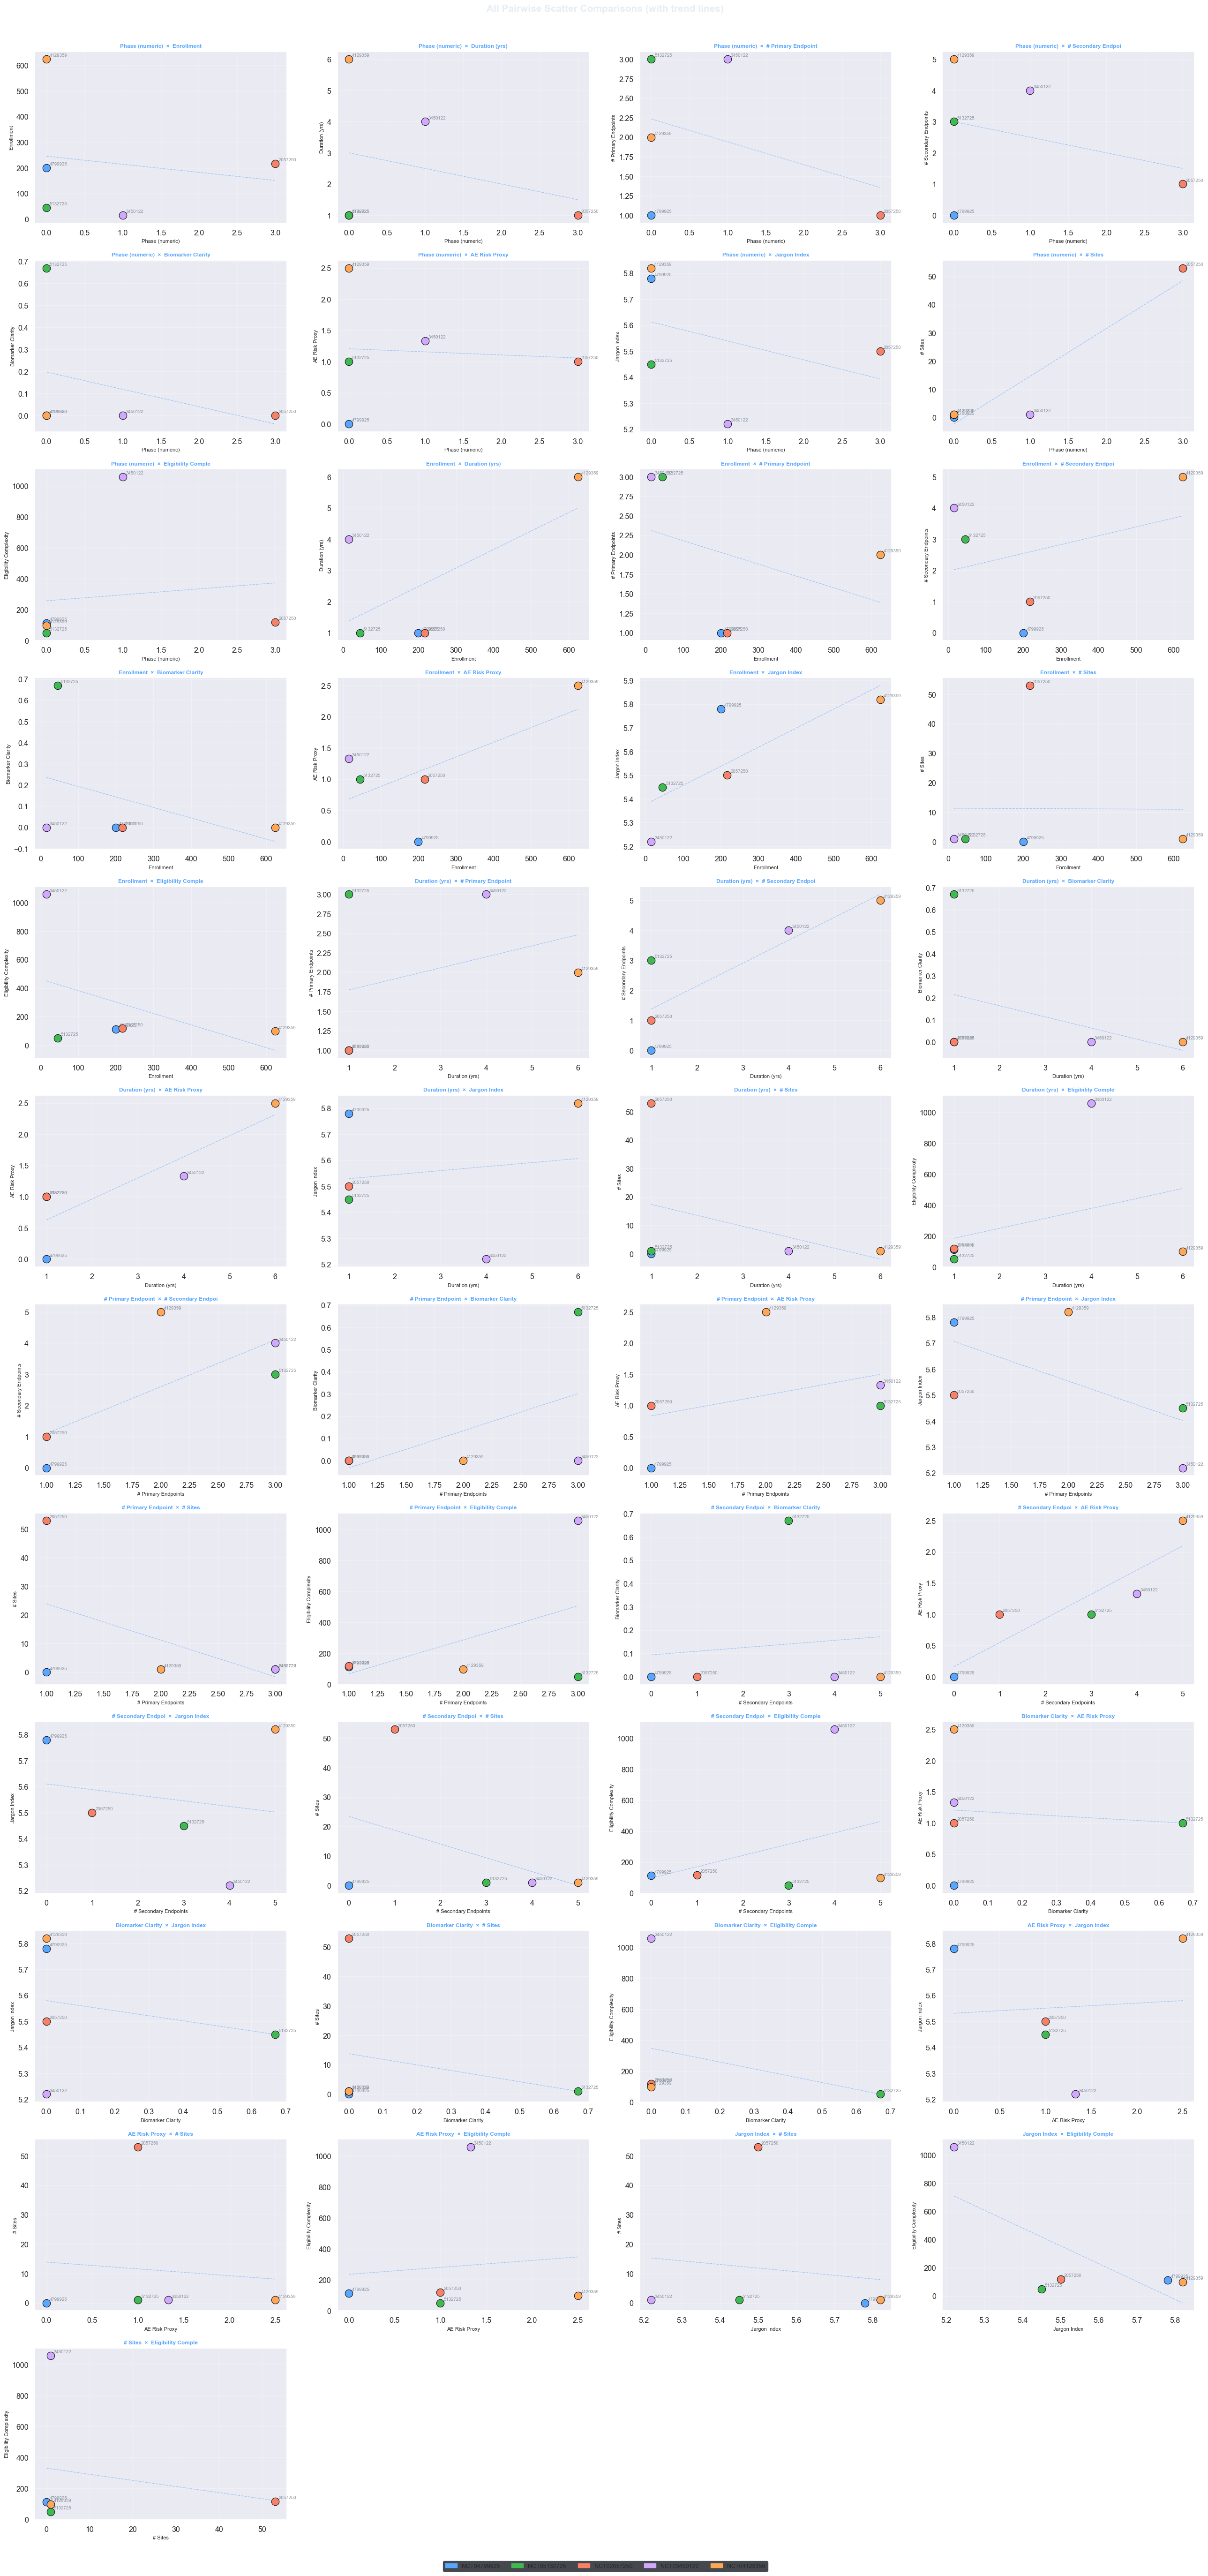


✅  45 unique combinations plotted


In [39]:
ncols = 4
nrows = int(np.ceil(len(combo_pairs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5*ncols, 4.5*nrows))
axes = axes.flatten()
study_ids = df["NCT ID"].tolist()

for idx, (xp, yp) in enumerate(combo_pairs):
    ax = axes[idx]
    xv = df[xp].astype(float).values
    yv = df[yp].astype(float).values

    for i, (x, y, sid) in enumerate(zip(xv, yv, study_ids)):
        ax.scatter(x, y, color=PALETTE[i], s=140, zorder=3,
                   edgecolors="#0d1117", linewidths=0.8)
        ax.annotate(sid[-7:], (x, y),
                    textcoords="offset points", xytext=(5,4),
                    fontsize=7, color="#8b949e")

    # trend line (numpy polyfit)
    mask = ~(np.isnan(xv) | np.isnan(yv))
    if mask.sum() > 1:
        z = np.polyfit(xv[mask], yv[mask], 1)
        xline = np.linspace(xv[mask].min(), xv[mask].max(), 50)
        ax.plot(xline, np.poly1d(z)(xline), color="#58a6ff", linewidth=1, alpha=0.5, linestyle="--")

    ax.set_xlabel(xp, fontsize=8)
    ax.set_ylabel(yp, fontsize=8)
    ax.set_title(f"{xp[:18]}  ×  {yp[:18]}", fontsize=8.5,
                 fontweight="bold", color="#58a6ff")
    ax.grid(True, alpha=0.25)

for j in range(idx+1, len(axes)):
    axes[j].set_visible(False)

handles = [mpatches.Patch(color=PALETTE[i], label=s) for i, s in enumerate(study_ids)]
fig.legend(handles=handles, loc="lower center", ncol=len(study_ids),
           bbox_to_anchor=(0.5, -0.01), fontsize=9)
fig.suptitle("All Pairwise Scatter Comparisons (with trend lines)",
             fontsize=15, fontweight="bold", color="#e6edf3", y=1.005)
plt.tight_layout()
plt.show()
print(f"\n✅  {len(combo_pairs)} unique combinations plotted")


## 🔗 Section 11 — Correlation Matrix (Pearson)

Pearson correlation computed (pandas + numpy verified)


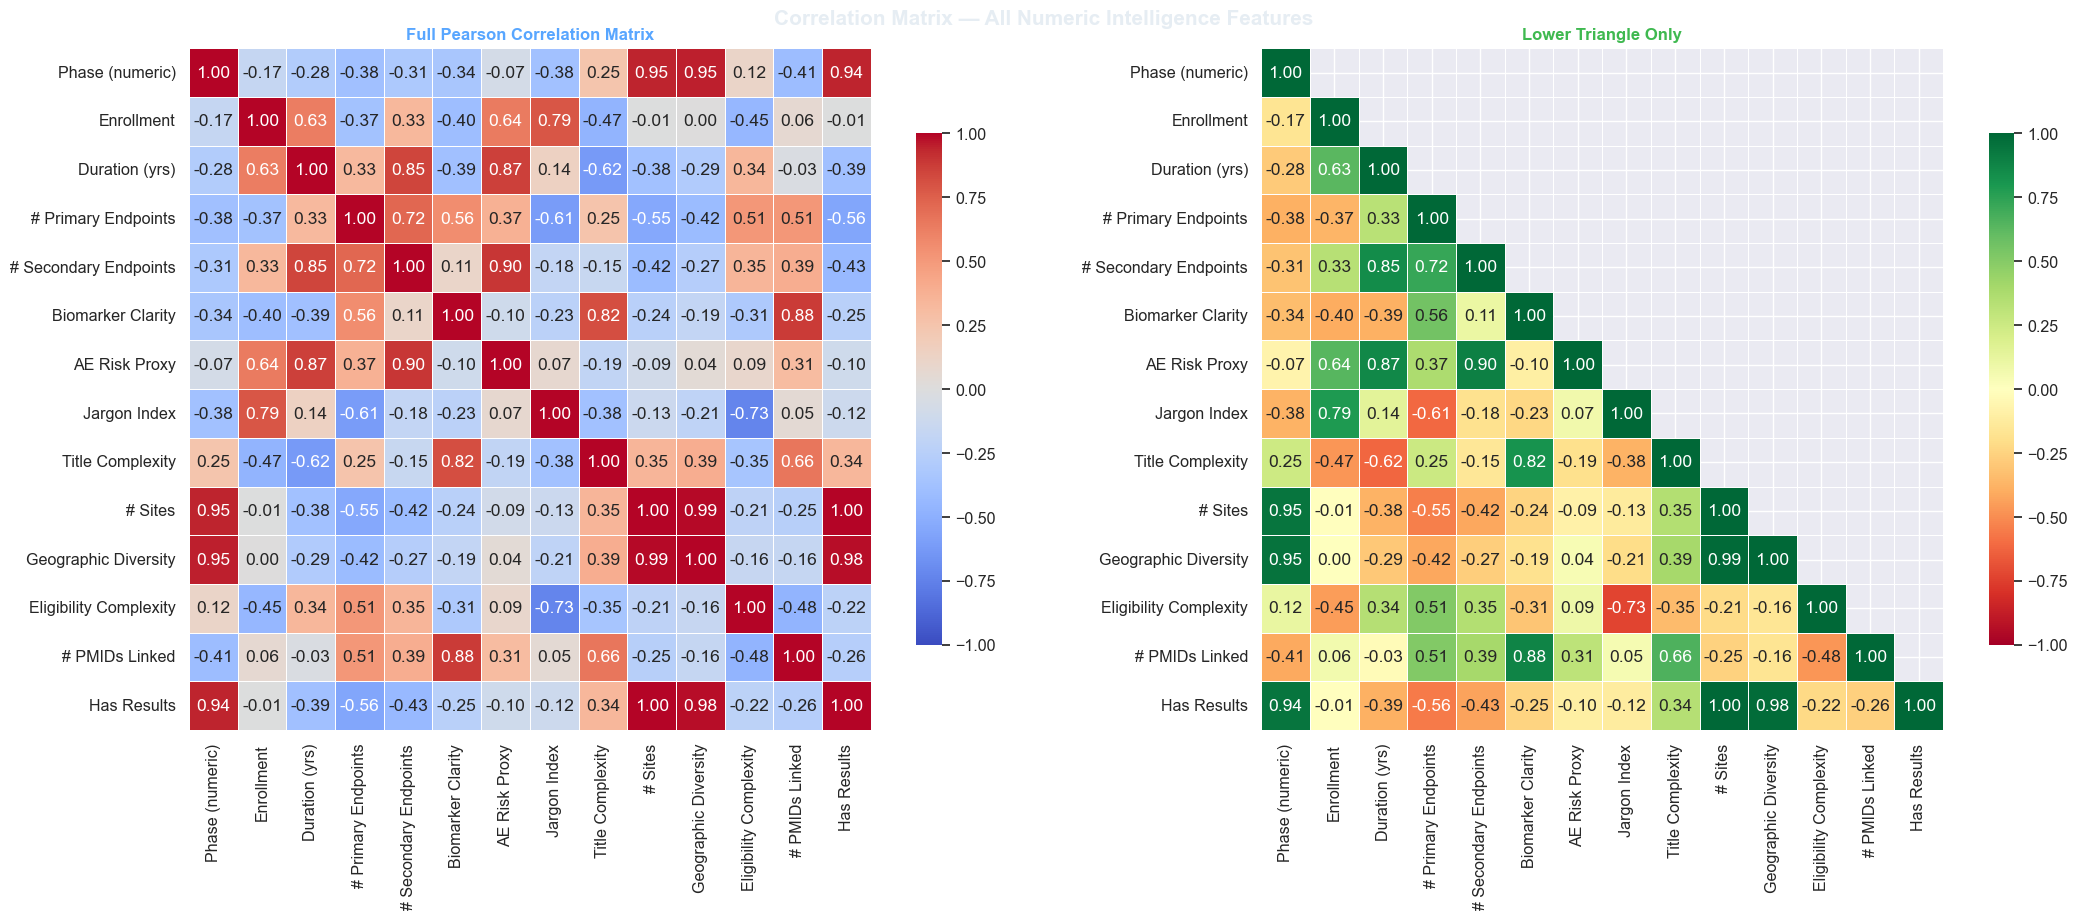

In [40]:
corr_cols = [
    "Phase (numeric)", "Enrollment", "Duration (yrs)",
    "# Primary Endpoints", "# Secondary Endpoints",
    "Biomarker Clarity", "AE Risk Proxy",
    "Jargon Index", "Title Complexity",
    "# Sites", "Geographic Diversity",
    "Eligibility Complexity", "# PMIDs Linked", "Has Results",
]

corr_df  = df[corr_cols].astype(float)
corr_mat = corr_df.corr(method="pearson")

# numpy verification
np_corr = np.corrcoef(corr_df.fillna(0).values.T)
print("Pearson correlation computed (pandas + numpy verified)")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(corr_mat, ax=axes[0], annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.4, cbar_kws={"shrink":0.75}, square=True)
axes[0].set_title("Full Pearson Correlation Matrix", fontweight="bold", color="#58a6ff", fontsize=12)

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, ax=axes[1], annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            mask=mask, linewidths=0.4, cbar_kws={"shrink":0.75}, square=True)
axes[1].set_title("Lower Triangle Only", fontweight="bold", color="#3fb950", fontsize=12)

fig.suptitle("Correlation Matrix — All Numeric Intelligence Features",
             fontsize=15, fontweight="bold", color="#e6edf3")
plt.tight_layout()
plt.show()


## 📈 Section 12 — Seaborn Pair-Plot (All Parameters)

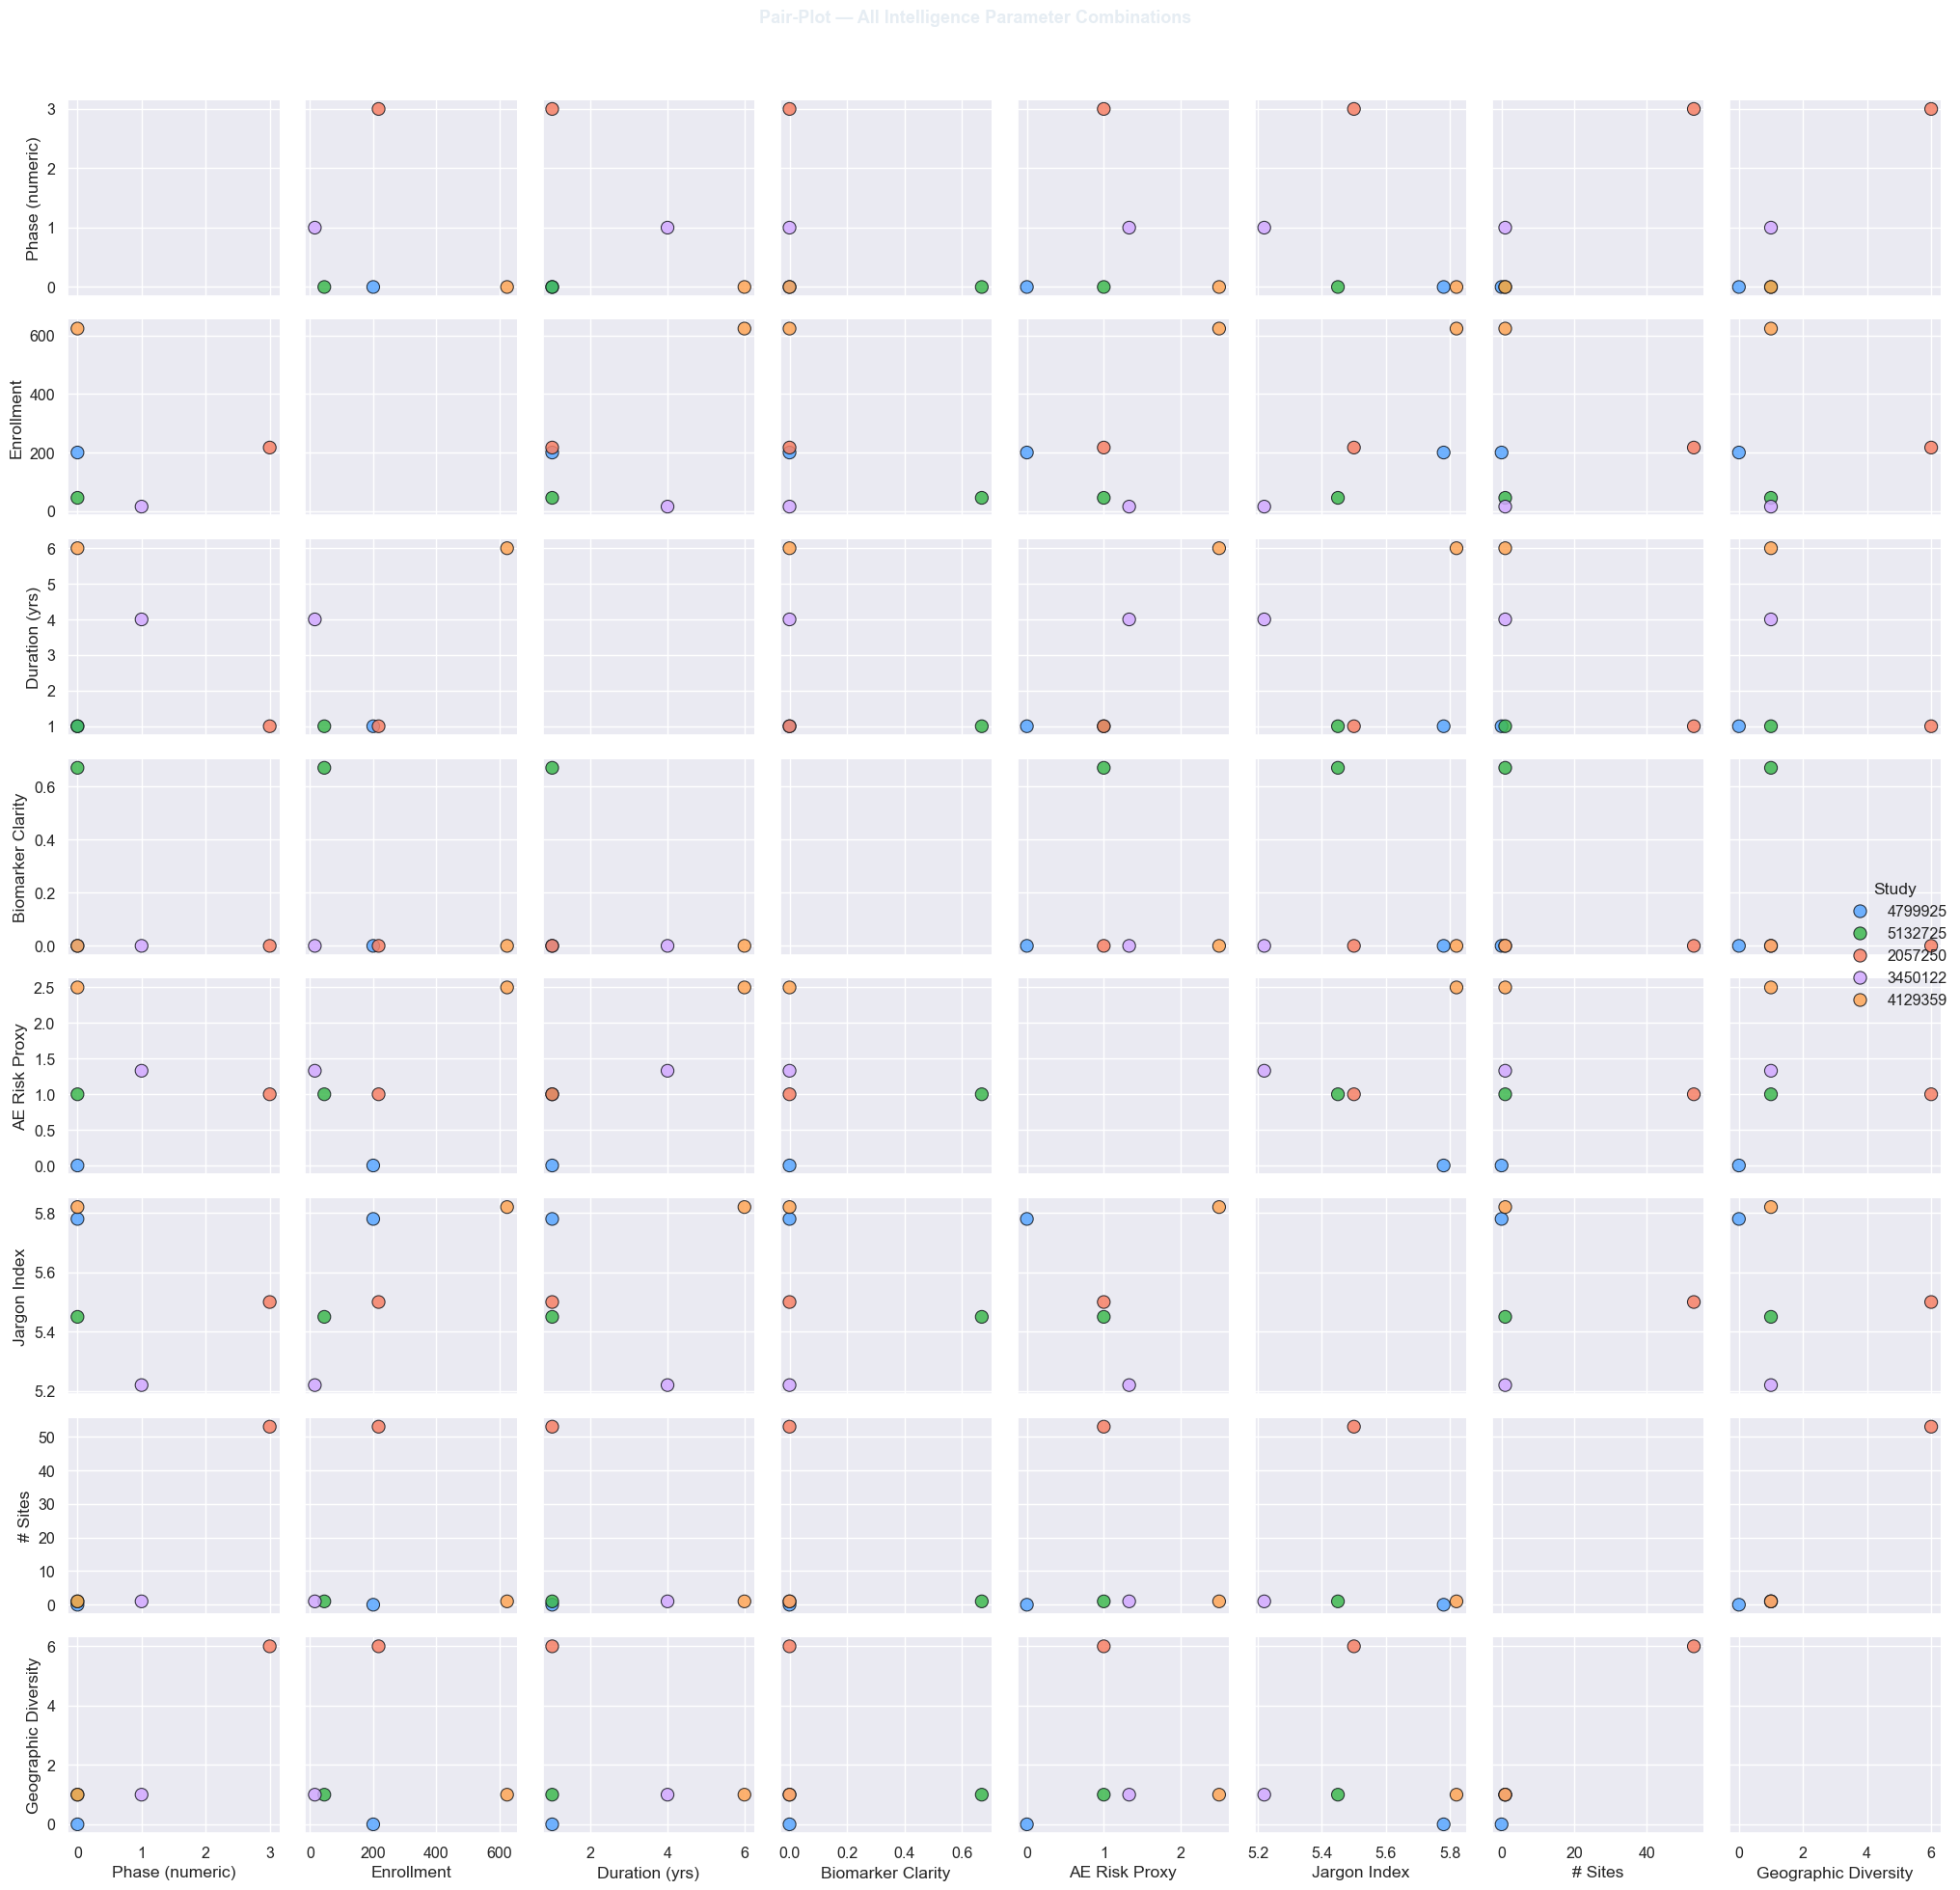

In [41]:
pp_cols = ["Phase (numeric)","Enrollment","Duration (yrs)",
           "Biomarker Clarity","AE Risk Proxy","Jargon Index",
           "# Sites","Geographic Diversity"]

pp_df = df[["NCT ID"] + pp_cols].copy()
pp_df["Study"] = pp_df["NCT ID"].str[-7:]

g = sns.pairplot(pp_df, hue="Study",
                 palette={s[-7:]: PALETTE[i] for i,s in enumerate(study_ids)},
                 diag_kind="kde",
                 plot_kws={"alpha":0.85,"s":90,"edgecolor":"#0d1117"},
                 height=2.4)
g.figure.suptitle("Pair-Plot — All Intelligence Parameter Combinations",
                  y=1.02, fontsize=13, fontweight="bold", color="#e6edf3")
plt.tight_layout()
plt.show()


## 🗺️ Section 13 — Categorical × Numeric Combination Heatmaps

`itertools.product` generates every combination of categorical parameter × numeric parameter.


Total categorical × numeric combos (itertools.product): 42


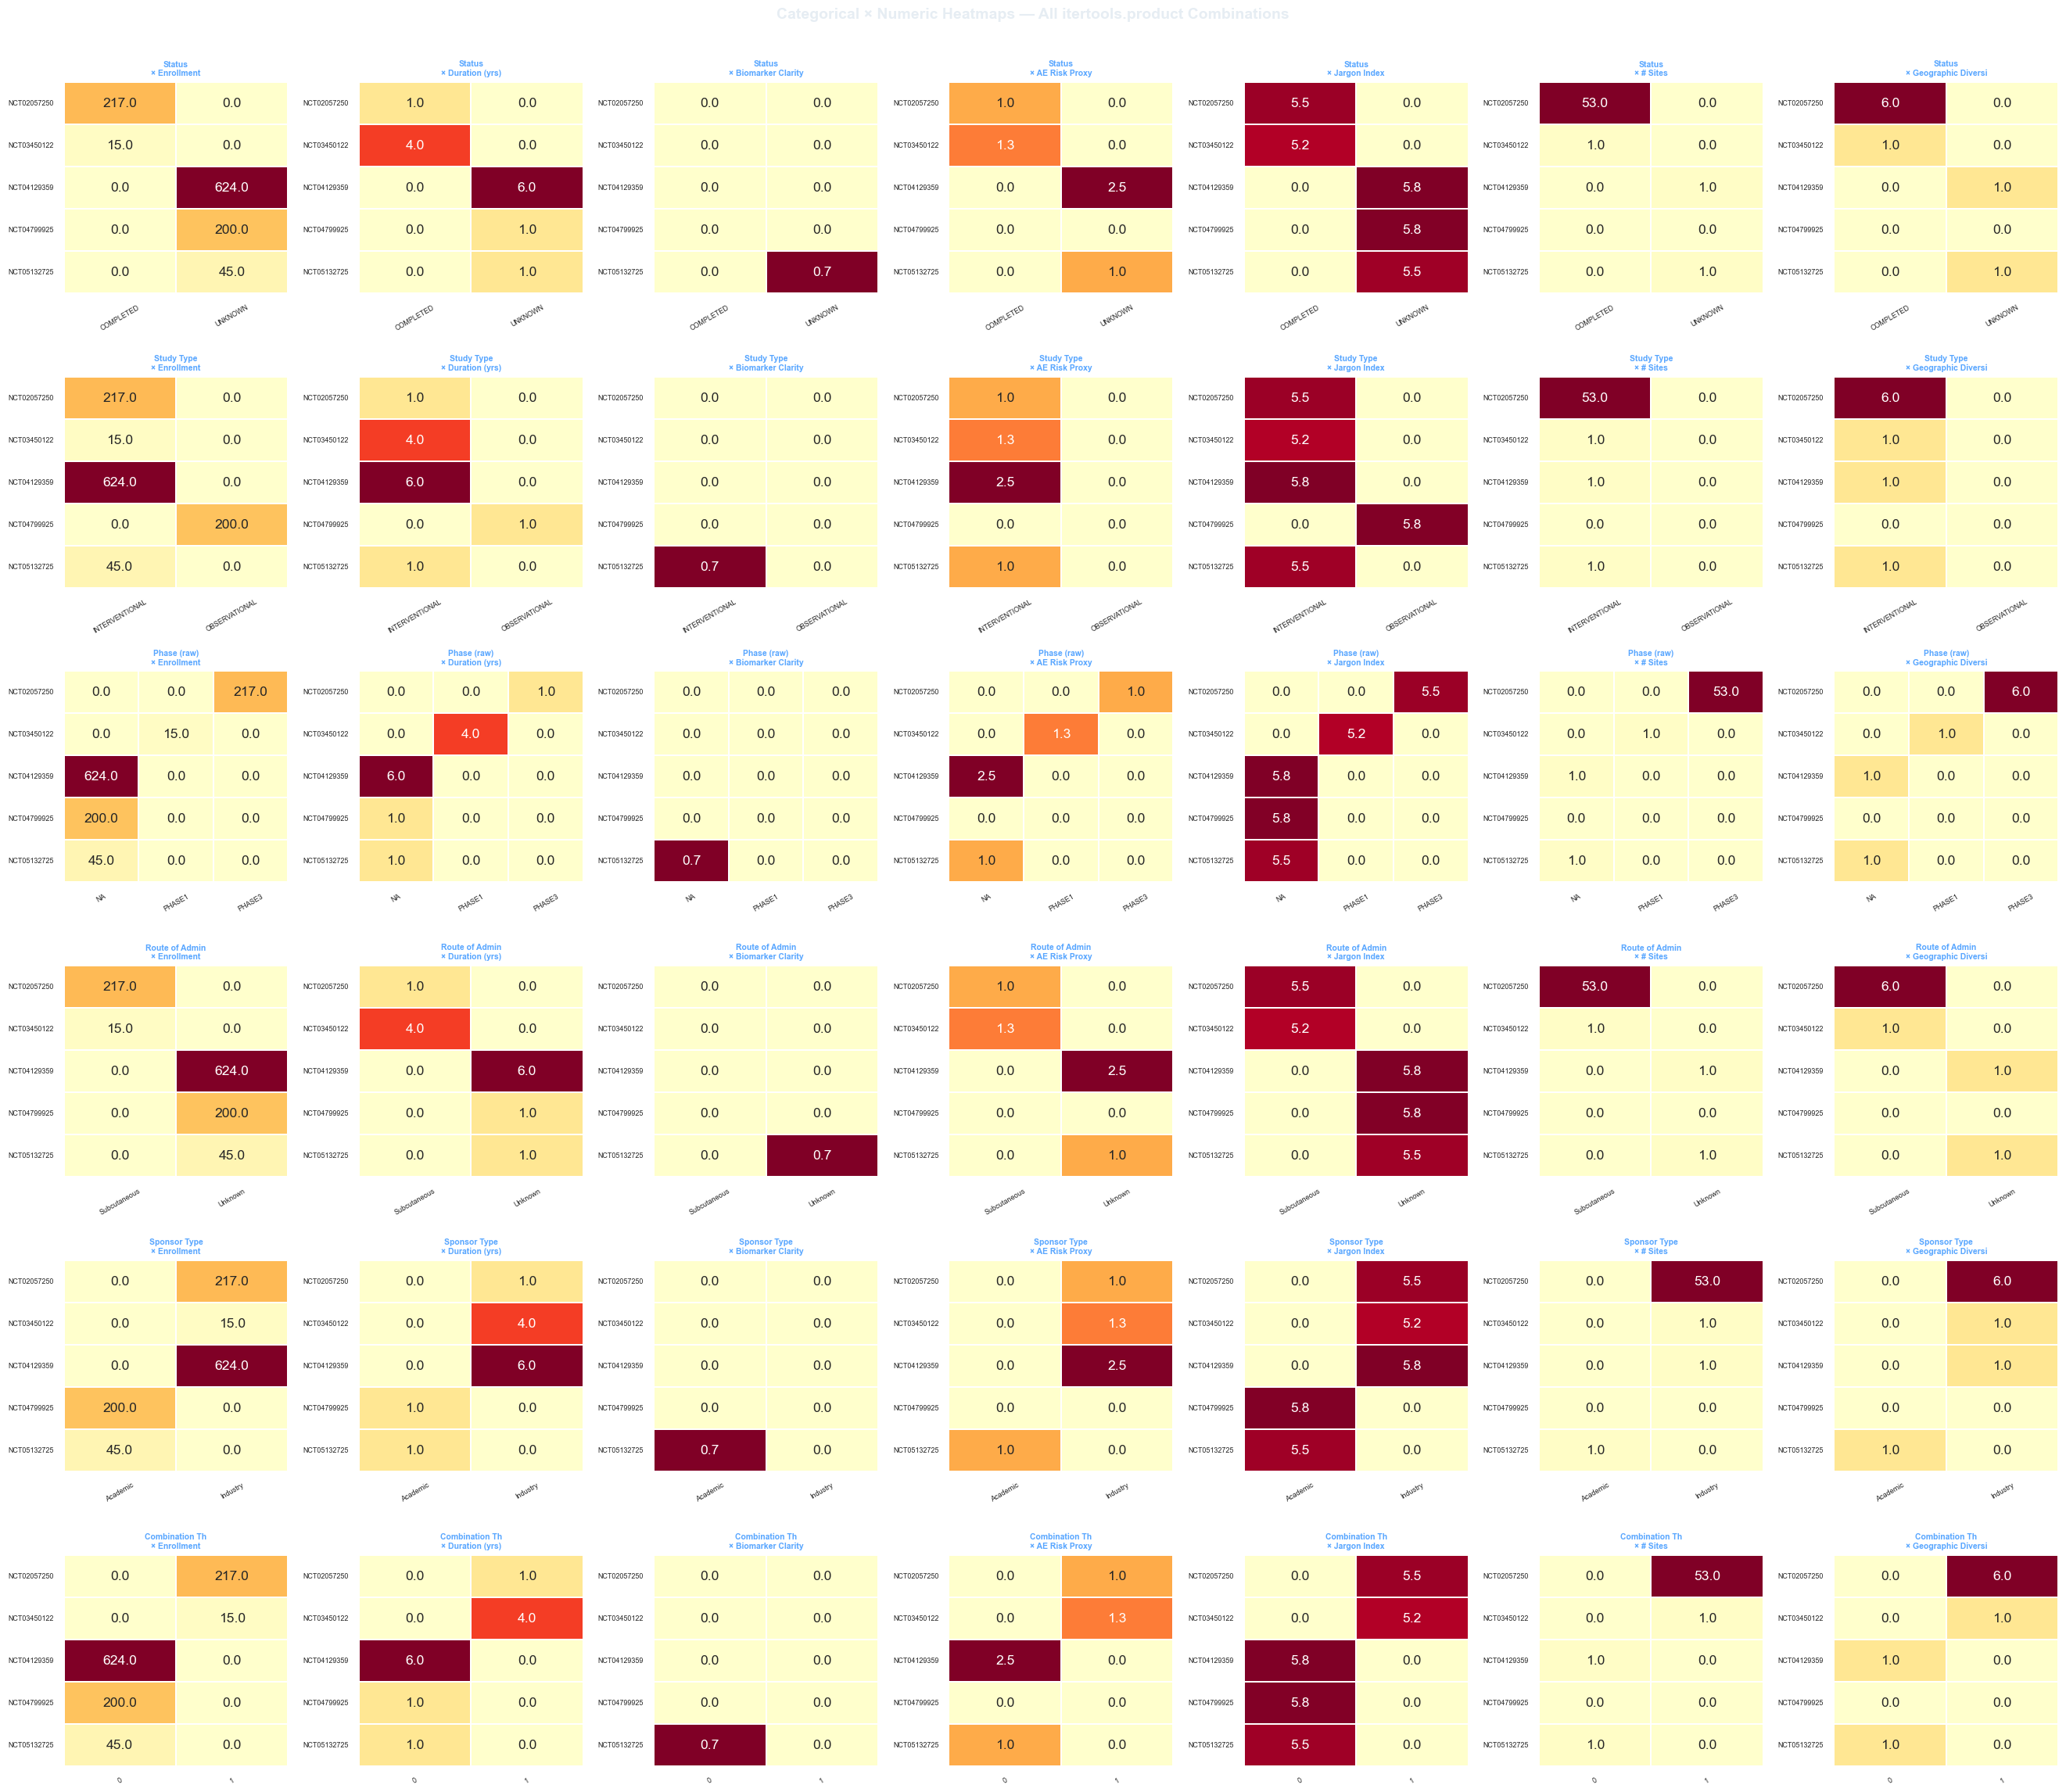

In [42]:
CAT_PARAMS = ["Status", "Study Type", "Phase (raw)",
              "Route of Admin (ROA)", "Sponsor Type", "Combination Therapy"]
NUM_HEAT   = ["Enrollment","Duration (yrs)","Biomarker Clarity",
              "AE Risk Proxy","Jargon Index","# Sites","Geographic Diversity"]

combos = list(itertools.product(CAT_PARAMS, NUM_HEAT))
print(f"Total categorical × numeric combos (itertools.product): {len(combos)}")

ncols = len(NUM_HEAT)
nrows = len(CAT_PARAMS)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.8*ncols, 3.8*nrows))

for row_i, cat in enumerate(CAT_PARAMS):
    for col_i, num in enumerate(NUM_HEAT):
        ax = axes[row_i][col_i]
        try:
            pivot = df.pivot_table(values=num, index="NCT ID", columns=cat,
                                   aggfunc="mean", fill_value=0)
            sns.heatmap(pivot, ax=ax, annot=True, fmt=".1f",
                        cmap="YlOrRd", cbar=False, linewidths=0.3)
        except Exception:
            ax.text(0.5, 0.5, "N/A", transform=ax.transAxes,
                    ha="center", va="center", color="#8b949e")
        ax.set_title(f"{cat[:14]}\n× {num[:18]}", fontsize=7.5,
                     color="#58a6ff", fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=6.5, rotation=30)
        ax.tick_params(axis="y", labelsize=6.5)

fig.suptitle("Categorical × Numeric Heatmaps — All itertools.product Combinations",
             fontsize=14, fontweight="bold", color="#e6edf3", y=1.005)
plt.tight_layout()
plt.show()


## 🕸️ Section 14 — Radar Chart — Multi-Axis Study Fingerprint

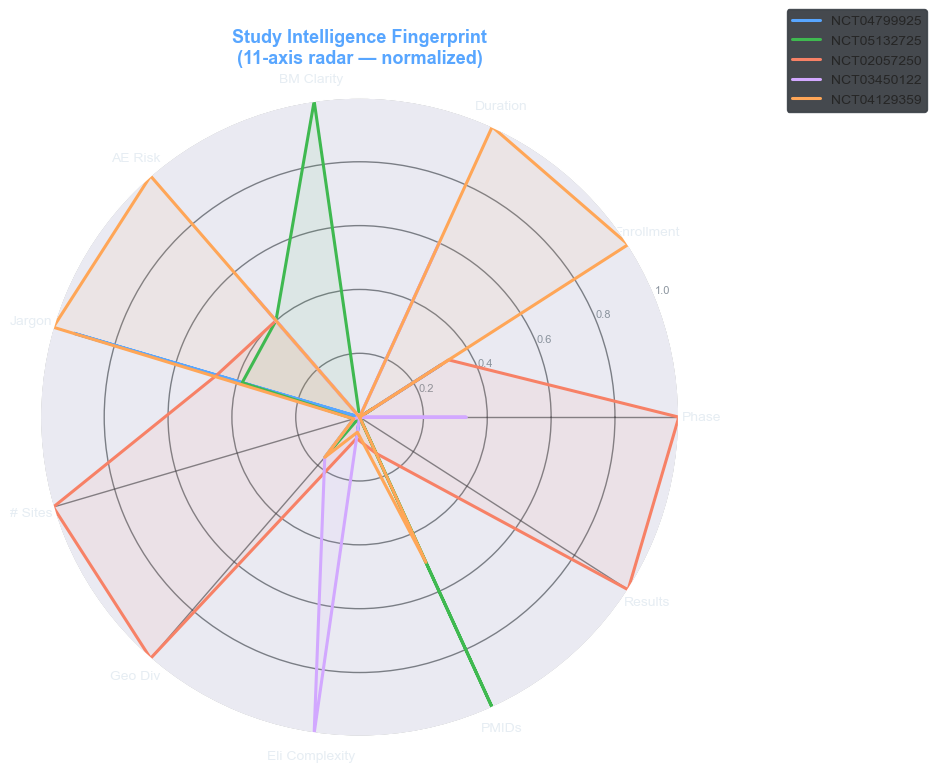

In [43]:
RADAR_PARAMS = [
    "Phase (numeric)", "Enrollment", "Duration (yrs)",
    "Biomarker Clarity", "AE Risk Proxy", "Jargon Index",
    "# Sites", "Geographic Diversity", "Eligibility Complexity",
    "# PMIDs Linked", "Has Results",
]
RADAR_LABELS = [
    "Phase", "Enrollment", "Duration",
    "BM Clarity", "AE Risk", "Jargon",
    "# Sites", "Geo Div", "Eli Complexity",
    "PMIDs", "Results",
]

radar_df = df[["NCT ID"] + RADAR_PARAMS].set_index("NCT ID").astype(float)
# Normalize 0–1 across studies
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

N = len(RADAR_PARAMS)
angles = [n / N * 2*pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, (study, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    color  = PALETTE[i % len(PALETTE)]
    ax.plot(angles, values, color=color, linewidth=2.2, label=study)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, size=10, color="#e6edf3")
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], color="#8b949e", size=8)
ax.set_ylim(0, 1)
ax.set_title("Study Intelligence Fingerprint\n(11-axis radar — normalized)",
             size=13, fontweight="bold", color="#58a6ff", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=10)
ax.grid(color="#30363d", alpha=0.6)
plt.tight_layout()
plt.show()


## 📊 Section 15 — Breakdown Charts: Phase, ROA, Sponsor, Status

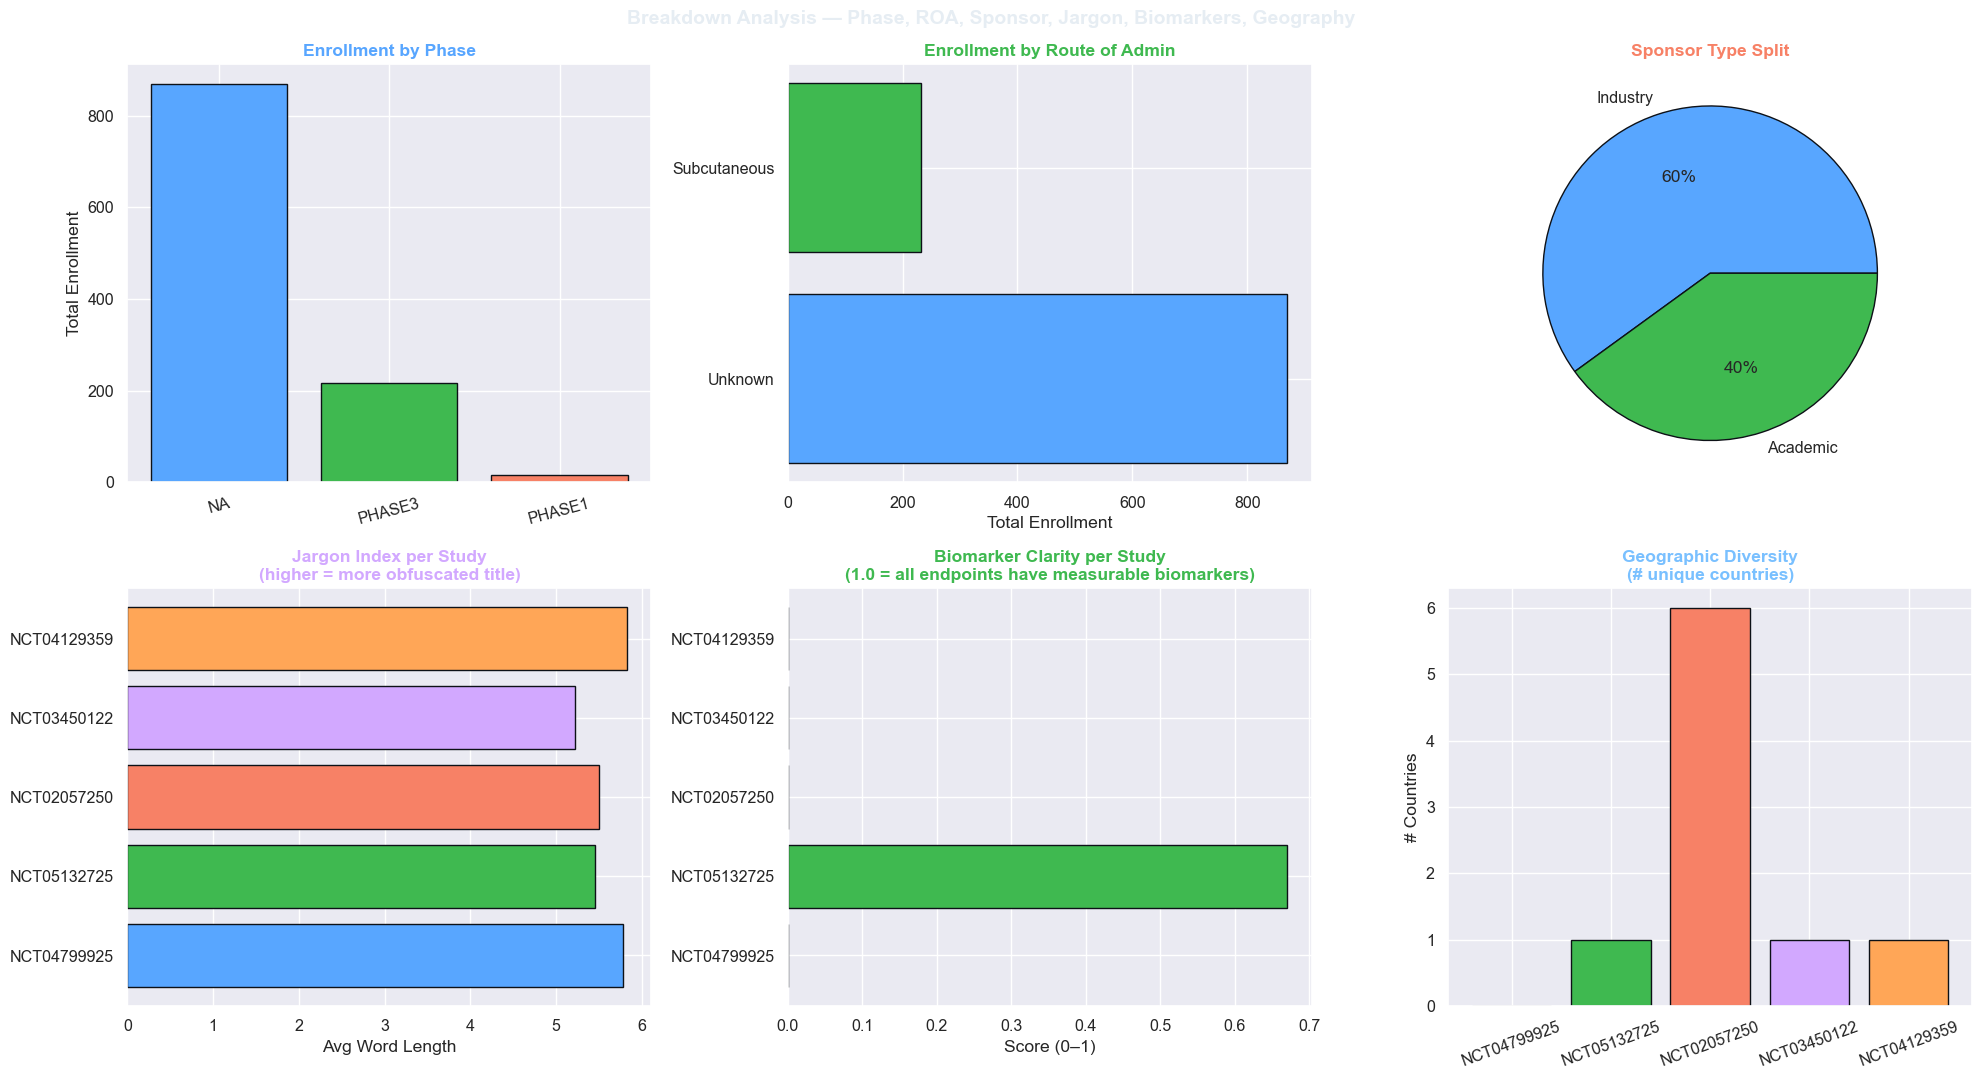

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. Enrollment by Phase
phase_enr = df.groupby("Phase (raw)")["Enrollment"].sum().sort_values(ascending=False)
axes[0][0].bar(phase_enr.index, phase_enr.values,
               color=PALETTE[:len(phase_enr)], edgecolor="#0d1117")
axes[0][0].set_title("Enrollment by Phase", fontweight="bold", color="#58a6ff")
axes[0][0].set_ylabel("Total Enrollment"); axes[0][0].tick_params(axis="x",rotation=15)

# 2. Enrollment by ROA
roa_enr = df.groupby("Route of Admin (ROA)")["Enrollment"].sum().sort_values(ascending=False)
axes[0][1].barh(roa_enr.index, roa_enr.values,
                color=PALETTE[:len(roa_enr)], edgecolor="#0d1117")
axes[0][1].set_title("Enrollment by Route of Admin", fontweight="bold", color="#3fb950")
axes[0][1].set_xlabel("Total Enrollment")

# 3. Sponsor type pie
spon_cnt = df["Sponsor Type"].value_counts()
axes[0][2].pie(spon_cnt.values, labels=spon_cnt.index,
               colors=PALETTE[:len(spon_cnt)], autopct="%1.0f%%",
               wedgeprops={"edgecolor":"#0d1117"})
axes[0][2].set_title("Sponsor Type Split", fontweight="bold", color="#f78166")

# 4. Jargon Index by study
axes[1][0].barh(df["NCT ID"], df["Jargon Index"], color=PALETTE[:len(df)], edgecolor="#0d1117")
axes[1][0].set_title("Jargon Index per Study\n(higher = more obfuscated title)",
                     fontweight="bold", color="#d2a8ff")
axes[1][0].set_xlabel("Avg Word Length")

# 5. Biomarker Clarity by study
axes[1][1].barh(df["NCT ID"], df["Biomarker Clarity"], color=PALETTE[:len(df)], edgecolor="#0d1117")
axes[1][1].set_title("Biomarker Clarity per Study\n(1.0 = all endpoints have measurable biomarkers)",
                     fontweight="bold", color="#3fb950")
axes[1][1].set_xlabel("Score (0–1)")

# 6. Geographic Diversity
axes[1][2].bar(df["NCT ID"], df["Geographic Diversity"].astype(float),
               color=PALETTE[:len(df)], edgecolor="#0d1117")
axes[1][2].set_title("Geographic Diversity\n(# unique countries)",
                     fontweight="bold", color="#79c0ff")
axes[1][2].set_ylabel("# Countries")
axes[1][2].tick_params(axis="x", rotation=20)

fig.suptitle("Breakdown Analysis — Phase, ROA, Sponsor, Jargon, Biomarkers, Geography",
             fontsize=14, fontweight="bold", color="#e6edf3")
plt.tight_layout()
plt.show()


## 📅 Section 16 — Trial Timeline (Gantt Chart)

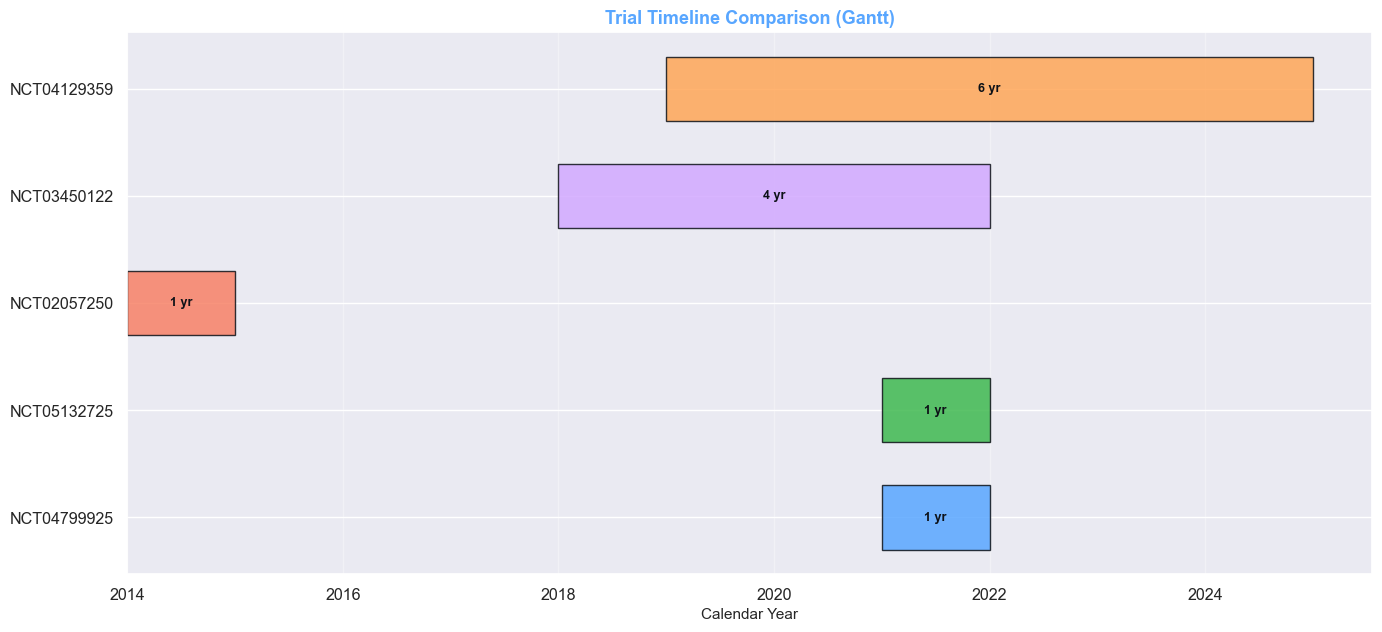

In [45]:
tl = df[["NCT ID","Short Label","Start Year","Duration (yrs)"]].dropna()

fig, ax = plt.subplots(figsize=(14, max(4, len(tl)*1.3)))
for i, row in tl.iterrows():
    color = PALETTE[i % len(PALETTE)]
    ax.barh(row["NCT ID"], row["Duration (yrs)"], left=row["Start Year"],
            color=color, edgecolor="#0d1117", alpha=0.85, height=0.6)
    ax.text(row["Start Year"] + row["Duration (yrs)"]/2, row["NCT ID"],
            f"{int(row['Duration (yrs)'])} yr", va="center", ha="center",
            fontsize=9, color="#0d1117", fontweight="bold")

ax.set_xlabel("Calendar Year", fontsize=11)
ax.set_title("Trial Timeline Comparison (Gantt)", fontsize=13,
             fontweight="bold", color="#58a6ff")
ax.grid(axis="x", alpha=0.35)
plt.tight_layout()
plt.show()


## 🏆 Section 17 — Composite Diligence Score (numpy dot product)

A weighted composite score across all 12 key intelligence parameters.

| Parameter | Weight | Rationale |
|---|---|---|
| Phase (numeric) | 0.18 | Later phase = more validated |
| Enrollment | 0.12 | Bigger = more powered |
| Duration (yrs) | 0.07 | Longer is more thorough |
| # Primary Endpoints | 0.15 | Clear endpoints = better design |
| Biomarker Clarity | 0.18 | Measurable endpoints = scientific rigor |
| AE Risk Proxy | 0.05 | Higher secondary = more safety monitoring |
| Jargon Index (inv) | 0.10 | Lower jargon = more transparent |
| # Sites | 0.05 | More sites = better generalizability |
| Geographic Diversity | 0.05 | Multi-country = broader validity |
| # PMIDs Linked | 0.05 | Literature-backed |


In [46]:
SCORE_PARAMS = [
    "Phase (numeric)", "Enrollment", "Duration (yrs)",
    "# Primary Endpoints", "Biomarker Clarity", "AE Risk Proxy",
    "Jargon Index", "# Sites", "Geographic Diversity", "# PMIDs Linked",
]
WEIGHTS = np.array([0.18, 0.12, 0.07, 0.15, 0.18, 0.05, 0.10, 0.05, 0.05, 0.05])
assert abs(WEIGHTS.sum() - 1.0) < 1e-9, "Weights must sum to 1"

score_df  = df[["NCT ID","Short Label","Sponsor Type","Phase (raw)","Route of Admin (ROA)"] + SCORE_PARAMS].copy()
arr_s     = score_df[SCORE_PARAMS].astype(float).fillna(0).values

# Normalize Jargon Index inversely (lower jargon = better)
jargon_col = SCORE_PARAMS.index("Jargon Index")
arr_s[:, jargon_col] = arr_s[:, jargon_col].max() - arr_s[:, jargon_col]

# Normalize 0–1 per column
col_min = arr_s.min(axis=0)
col_max = arr_s.max(axis=0)
arr_norm = (arr_s - col_min) / (col_max - col_min + 1e-9)

# Composite = weighted dot product (numpy)
scores = arr_norm @ WEIGHTS
score_df["Diligence Score"] = scores.round(4)
score_df["Score (%)"]       = (scores * 100).round(1)

print("\n🏆  MindReader Composite Diligence Scores:")
display(score_df[["NCT ID","Short Label","Phase (raw)","Route of Admin (ROA)",
                  "Sponsor Type","Score (%)"]].sort_values("Score (%)", ascending=False))



🏆  MindReader Composite Diligence Scores:


,NCT ID,Short Label,Phase (raw),Route of Admin (ROA),Sponsor Type,Score (%)
1,NCT05132725,Carbohydrate Counting and DASH Intervention Among …,NA,Unknown,Academic,47.7
2,NCT02057250,To Evaluate Sarilumab - SAR153191 (REGN88) - Auto-…,PHASE3,Subcutaneous,Industry,39.9
3,NCT03450122,"Modified T Cells, Chemotherapy, and Aldesleukin Wi…",PHASE1,Subcutaneous,Industry,38.8
4,NCT04129359,FamilieTrivsel i Almen Praksis: a Mentalisation Pr…,NA,Unknown,Industry,34.9
0,NCT04799925,Hyperuricemia and Diabetic Nephropathy,NA,Unknown,Academic,4.3


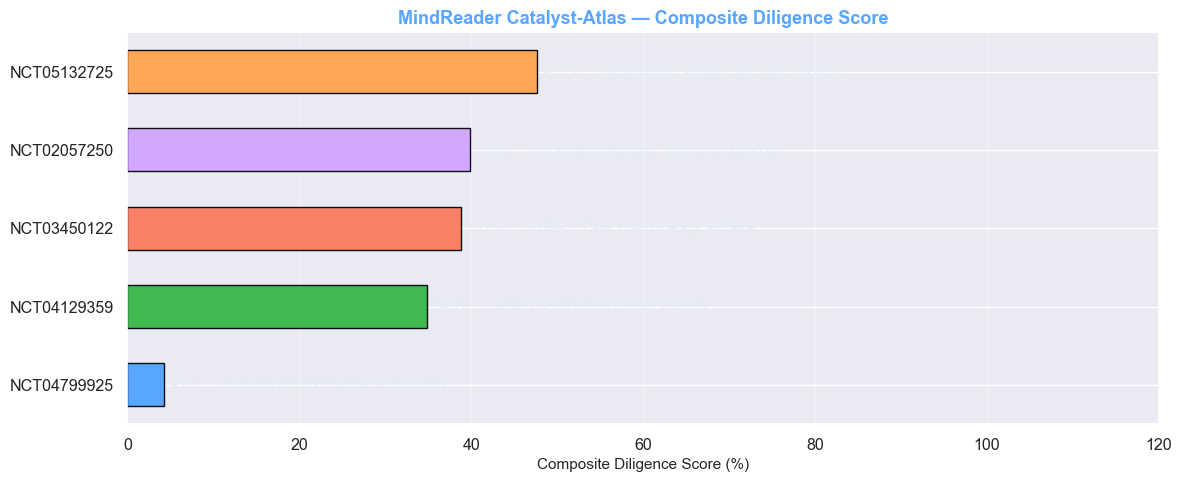

In [47]:
# Score bar chart
sorted_s = score_df.sort_values("Score (%)", ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(sorted_s["NCT ID"], sorted_s["Score (%)"],
               color=[PALETTE[i % len(PALETTE)] for i in range(len(sorted_s))],
               edgecolor="#0d1117", height=0.55)

for bar, val, sl in zip(bars, sorted_s["Score (%)"], sorted_s["Short Label"]):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%  ·  {sl[:40]}", va="center", fontsize=9, color="#e6edf3")

ax.set_xlim(0, 120)
ax.set_xlabel("Composite Diligence Score (%)", fontsize=11)
ax.set_title("MindReader Catalyst-Atlas — Composite Diligence Score",
             fontsize=13, fontweight="bold", color="#58a6ff")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 📋 Section 18 — Score Contribution by Parameter (Stacked)

Per-parameter weighted contributions:


,Phase (numeric),Enrollment,Duration (yrs),# Primary Endpoints,Biomarker Clarity,AE Risk Proxy,Jargon Index,# Sites,Geographic Diversity,# PMIDs Linked,Total
NCT04799925,0.00,0.0365,0.000,0.000,0.00,0.0000,0.0067,0.0000,0.0000,0.0000,0.0431
NCT05132725,0.00,0.0059,0.000,0.150,0.18,0.0200,0.0617,0.0009,0.0083,0.0500,0.4769
NCT02057250,0.18,0.0398,0.000,0.000,0.00,0.0200,0.0533,0.0500,0.0500,0.0062,0.3994
NCT03450122,0.06,0.0000,0.042,0.150,0.00,0.0266,0.1000,0.0009,0.0083,0.0000,0.3879
NCT04129359,0.00,0.1200,0.070,0.075,0.00,0.0500,0.0000,0.0009,0.0083,0.0250,0.3493


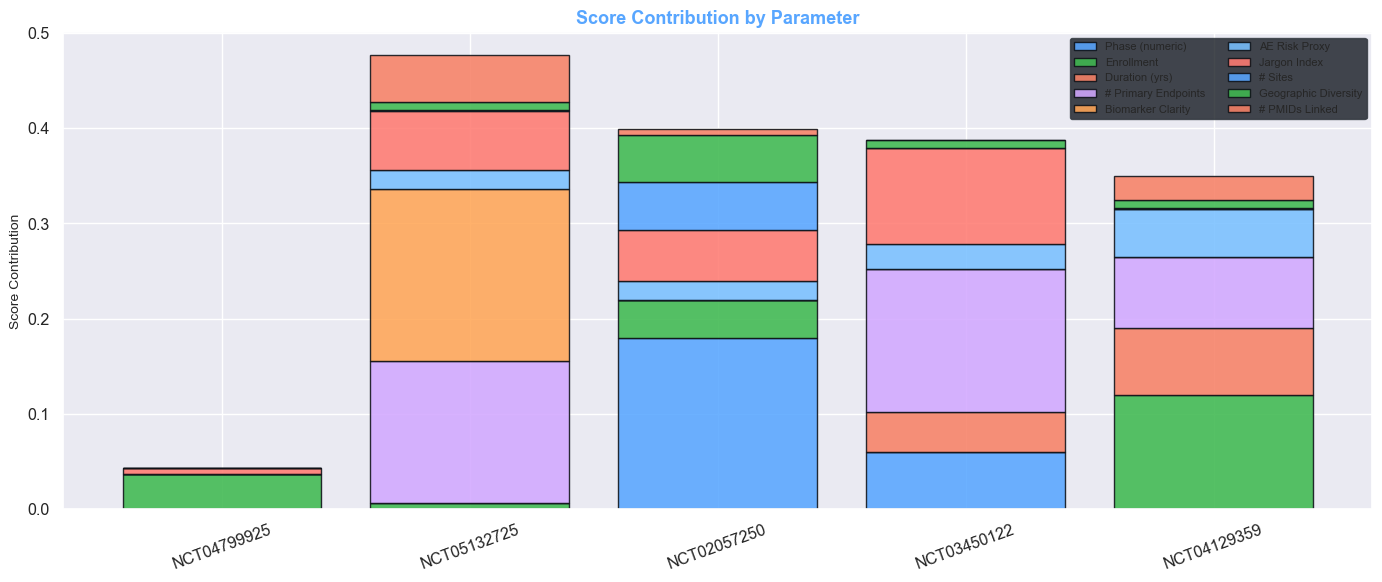

In [48]:
contrib = arr_norm * WEIGHTS
contrib_df = pd.DataFrame(contrib, columns=SCORE_PARAMS,
                           index=score_df["NCT ID"].values)
contrib_df["Total"] = scores

print("Per-parameter weighted contributions:")
display(contrib_df.round(4))

bottom = np.zeros(len(contrib_df))
fig, ax = plt.subplots(figsize=(14, 6))
for j, col in enumerate(SCORE_PARAMS):
    vals = contrib_df[col].values
    ax.bar(contrib_df.index, vals, bottom=bottom,
           label=col, color=PALETTE[j % len(PALETTE)],
           edgecolor="#0d1117", alpha=0.88)
    bottom += vals

ax.set_ylabel("Score Contribution", fontsize=10)
ax.set_title("Score Contribution by Parameter", fontsize=13,
             fontweight="bold", color="#58a6ff")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 🥇 Section 19 — Rank Table: Every Study vs Every Parameter

🏅  Study rankings per parameter (1 = best in category):


,Phase (numeric),Enrollment,Duration (yrs),# Primary Endpoints,Biomarker Clarity,AE Risk Proxy,Jargon Index,# Sites,Geographic Diversity,# PMIDs Linked
NCT ID,,,,,,,,,,
NCT04799925,3,3,3,4,2,5,2,5,5,4
NCT05132725,3,4,3,1,1,3,4,2,2,1
NCT02057250,1,2,3,4,2,3,3,1,1,3
NCT03450122,2,5,2,1,2,2,5,2,2,4
NCT04129359,3,1,1,3,2,1,1,2,2,2


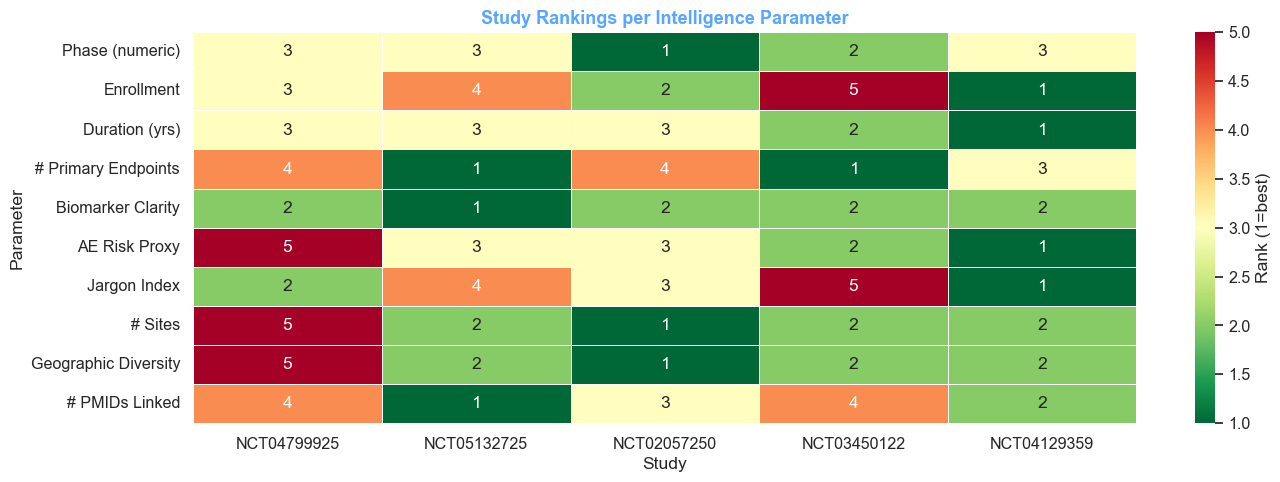

In [49]:
rank_df  = df[["NCT ID"] + SCORE_PARAMS].set_index("NCT ID").astype(float).fillna(0)
rank_tbl = rank_df.rank(ascending=False, method="min").astype(int)

print("🏅  Study rankings per parameter (1 = best in category):")
display(rank_tbl)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(rank_tbl.T, annot=True, fmt="d",
            cmap="RdYlGn_r", linewidths=0.5, ax=ax,
            cbar_kws={"label":"Rank (1=best)"})
ax.set_title("Study Rankings per Intelligence Parameter",
             fontsize=13, fontweight="bold", color="#58a6ff")
ax.set_xlabel("Study"); ax.set_ylabel("Parameter")
plt.tight_layout()
plt.show()


## 🔄 Section 20 — 2-Way Cross-Tabulations (itertools.combinations)

All pairwise categorical cross-tabs to reveal co-occurrence patterns.


In [50]:
CT_PARAMS = ["Status","Study Type","Phase (raw)","Route of Admin (ROA)",
             "Sponsor Type","Combination Therapy"]

cat_combos = list(itertools.combinations(CT_PARAMS, 2))
print(f"2-way categorical combinations: {len(cat_combos)}")

for c1, c2 in cat_combos:
    print(f"\n📌  {c1}  ×  {c2}")
    ct = pd.crosstab(df[c1], df[c2], margins=True)
    display(ct)


2-way categorical combinations: 15

📌  Status  ×  Study Type


Study Type,INTERVENTIONAL,OBSERVATIONAL,All
Status,,,
COMPLETED,2,0,2
UNKNOWN,2,1,3
All,4,1,5



📌  Status  ×  Phase (raw)


Phase (raw),NA,PHASE1,PHASE3,All
Status,,,,
COMPLETED,0,1,1,2
UNKNOWN,3,0,0,3
All,3,1,1,5



📌  Status  ×  Route of Admin (ROA)


...

Sponsor Type,Academic,Industry,All
Route of Admin (ROA),,,
Subcutaneous,0,2,2
Unknown,2,1,3
All,2,3,5



📌  Route of Admin (ROA)  ×  Combination Therapy


Combination Therapy,0,1,All
Route of Admin (ROA),,,
Subcutaneous,0,2,2
Unknown,3,0,3
All,3,2,5



📌  Sponsor Type  ×  Combination Therapy


Combination Therapy,0,1,All
Sponsor Type,,,
Academic,2,0,2
Industry,1,2,3
All,3,2,5


## 🔤 Section 21 — Jargon & Title Complexity Deep Dive

One of MindReader's signature features: **flagging clinical trials that use overly dense,
obfuscated language** — a potential signal of weak endpoints being hidden behind complexity.


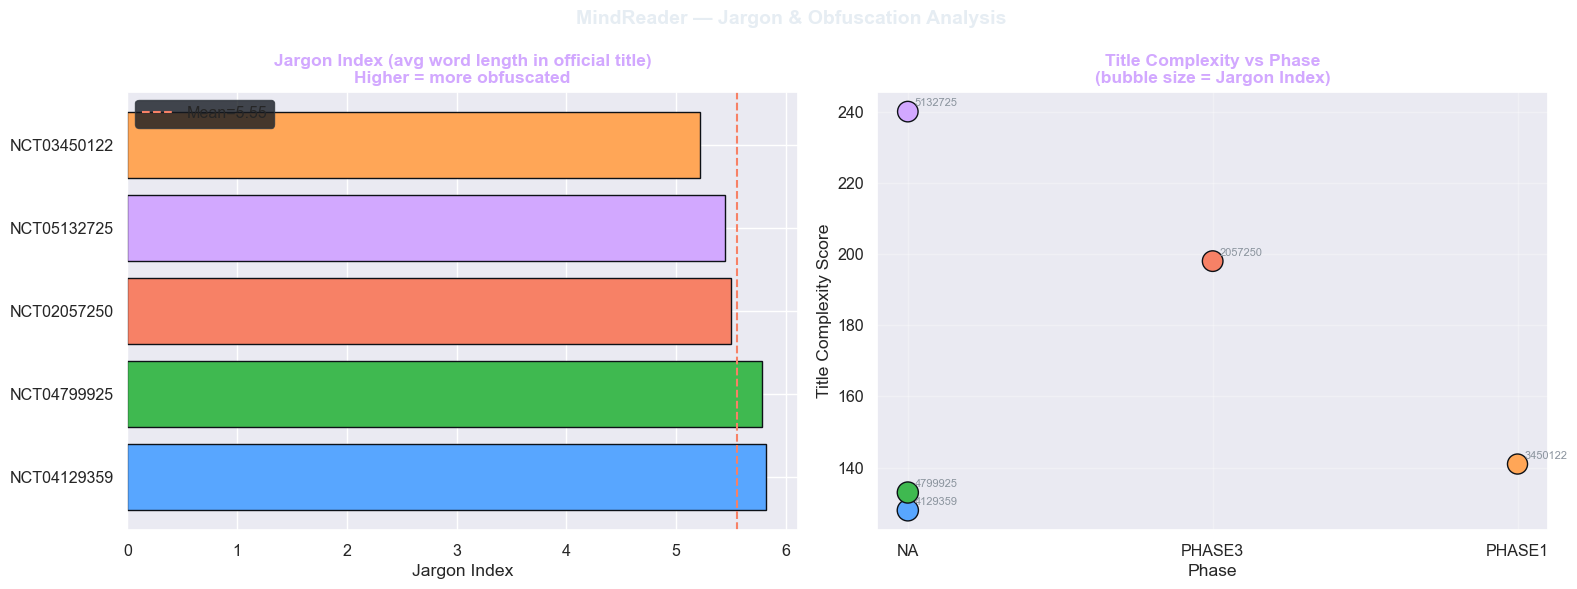


📊  Studies ranked by title complexity (most obfuscated first):
  [NCT04129359] Jargon=5.82 | Complexity=128
    → NCT04129359
  [NCT04799925] Jargon=5.78 | Complexity=133
    → NCT04799925
  [NCT02057250] Jargon=5.50 | Complexity=198
    → NCT02057250
  [NCT05132725] Jargon=5.45 | Complexity=240
    → NCT05132725
  [NCT03450122] Jargon=5.22 | Complexity=141
    → NCT03450122


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Jargon Index bar
jdf = df[["NCT ID","Jargon Index","Title Complexity","Phase (raw)"]].sort_values(
    "Jargon Index", ascending=False)

axes[0].barh(jdf["NCT ID"], jdf["Jargon Index"],
             color=[PALETTE[i] for i in range(len(jdf))], edgecolor="#0d1117")
axes[0].axvline(jdf["Jargon Index"].mean(), color="#f78166",
                linewidth=1.5, linestyle="--", label=f"Mean={jdf['Jargon Index'].mean():.2f}")
axes[0].set_title("Jargon Index (avg word length in official title)\nHigher = more obfuscated",
                  fontweight="bold", color="#d2a8ff")
axes[0].set_xlabel("Jargon Index"); axes[0].legend()

# Title Complexity scatter vs Phase
axes[1].scatter(jdf["Phase (raw)"], jdf["Title Complexity"],
                s=[jdf["Jargon Index"].iloc[i]*40 for i in range(len(jdf))],
                c=PALETTE[:len(jdf)], edgecolors="#0d1117", zorder=3)
for _, row in jdf.iterrows():
    axes[1].annotate(row["NCT ID"][-7:], (row["Phase (raw)"], row["Title Complexity"]),
                     textcoords="offset points", xytext=(5,4), fontsize=8, color="#8b949e")
axes[1].set_title("Title Complexity vs Phase\n(bubble size = Jargon Index)",
                  fontweight="bold", color="#d2a8ff")
axes[1].set_xlabel("Phase"); axes[1].set_ylabel("Title Complexity Score")
axes[1].grid(alpha=0.3)

fig.suptitle("MindReader — Jargon & Obfuscation Analysis",
             fontsize=14, fontweight="bold", color="#e6edf3")
plt.tight_layout()
plt.show()

# Print the actual titles ranked by complexity
print("\n📊  Studies ranked by title complexity (most obfuscated first):")
for _, row in jdf.iterrows():
    print(f"  [{row['NCT ID']}] Jargon={row['Jargon Index']:.2f} | Complexity={row['Title Complexity']:.0f}")
    print(f"    → {row['NCT ID']}")


---

## ✅ Analysis Complete — MindReader Intelligence Pipeline

### What This Notebook Demonstrates

```
ClinicalTrials.gov API v2 (all 14 modules)
        ↓
PubMed / NCBI Entrez (linked papers)
        ↓
Derived Feature Engine
  • Jargon Index          • Biomarker Clarity
  • Title Complexity      • AE Risk Proxy
  • Route of Admin (ROA)  • Eligibility Complexity
  • Combination Therapy   • Geographic Diversity
  • Sponsor Type
        ↓
Full Comparative Analytics
  • All pairwise scatters (itertools.combinations)
  • Pearson correlation matrix (numpy + pandas)
  • Full pair-plot (seaborn)
  • Categorical × Numeric heatmaps (itertools.product)
  • 2-way cross-tabulations (itertools.combinations)
  • Radar fingerprint (11-axis)
  • Composite diligence score (numpy dot product)
  • Score contribution breakdown
  • Rank table heatmap
  • Jargon & obfuscation deep dive
```